# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

## **Acknowledgment**

### In the process of completing the assignment 1 was used Generative AI specificaly Claude to fix parts of my code and writing correctly REALME file in the GitHub repository. To be more precise in the code part it helped me with fixing the problem in the code after appeared errors, while running the code.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Define the data source
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

data = pd.read_csv(url)

len(data)

7214

In [3]:
data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [4]:
# Define variable groups
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]
# --------------------------------------------------------
# DATA CLEANING (Selecting relevant columns, fixing types)
# --------------------------------------------------------
# Select columns (equivalent to dplyr::select)
columns_to_keep = ["age", "c_charge_degree", "race", "age_cat", "score_text",
                   "sex", "priors_count", "days_b_screening_arrest",
                   "decile_score", "is_recid", "two_year_recid",
                   "c_jail_in", "c_jail_out"]

df = data[columns_to_keep].copy()
# -------------------------------------------------------
# FILTERING (equivalent to filter())
# -------------------------------------------------------
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

#-------------------------------------------------------
# VARIABLE TRANSFORMATION (Converting data types)
#-------------------------------------------------------
# Type conversions
# Convert datetime columns
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert non-numeric/non-datetime columns to categorical (equivalent to as.factor)
factor_cols = [c for c in df.columns if c not in numeric_vars + datetime_vars]
for col in factor_cols:
    df[col] = df[col].astype("category")

# -----------------------------------------------------
# FEATURE CONSTRUCTION (Creating new variables)
# -----------------------------------------------------
# Derived factors with reference levels
# crime_factor
df["crime_factor"] = df["c_charge_degree"].astype("category")

# age_factor with reference level "25 - 45"
df["age_factor"] = pd.Categorical(df["age_cat"])
df["age_factor"] = df["age_factor"].cat.reorder_categories(
    ["25 - 45"] + [c for c in df["age_factor"].cat.categories if c != "25 - 45"]
)

# race_factor with reference level "Caucasian"
df["race_factor"] = pd.Categorical(df["race"])
df["race_factor"] = df["race_factor"].cat.reorder_categories(
    ["Caucasian"] + [c for c in df["race_factor"].cat.categories if c != "Caucasian"]
)

# gender_factor with labels and reference level "Male"
df["gender_factor"] = df["sex"].map({"Female": "Female", "Male": "Male"}).astype("category")
df["gender_factor"] = df["gender_factor"].cat.reorder_categories(["Male", "Female"])

# score_factor: Low vs High score
df["score_factor"] = pd.Categorical(
    df["score_text"].apply(lambda x: "LowScore" if x == "Low" else "HighScore"),
    categories=["LowScore", "HighScore"]
)

# Row count
len(df)

6172

In [5]:
# See first 10 rows
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [6]:
# Shows type, number of data and other information for each variable
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

In [7]:
# Calculate the length of stay in days
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

# Calculate correlation
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.20747808478031807)

In [8]:
# Counts number of people of each age range given in the data
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [9]:
# Counts number of people in each race given in the data
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [10]:
# Prints ratio of each race in the given dataset

print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
# Counts number of people with different score text
df["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


In [12]:
# Cross-tabulation of sex and race
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
# Count of each sex category
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [14]:
# Print ratio of men and women in the dataset
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [15]:
# Count of defendants who recidivated within two years
len(df[df["two_year_recid"] == 1])

2809

In [16]:
# Percentage of defendants who recidivated
len(df[df["two_year_recid"] == 1]) / len(df) * 100

45.51198963058976

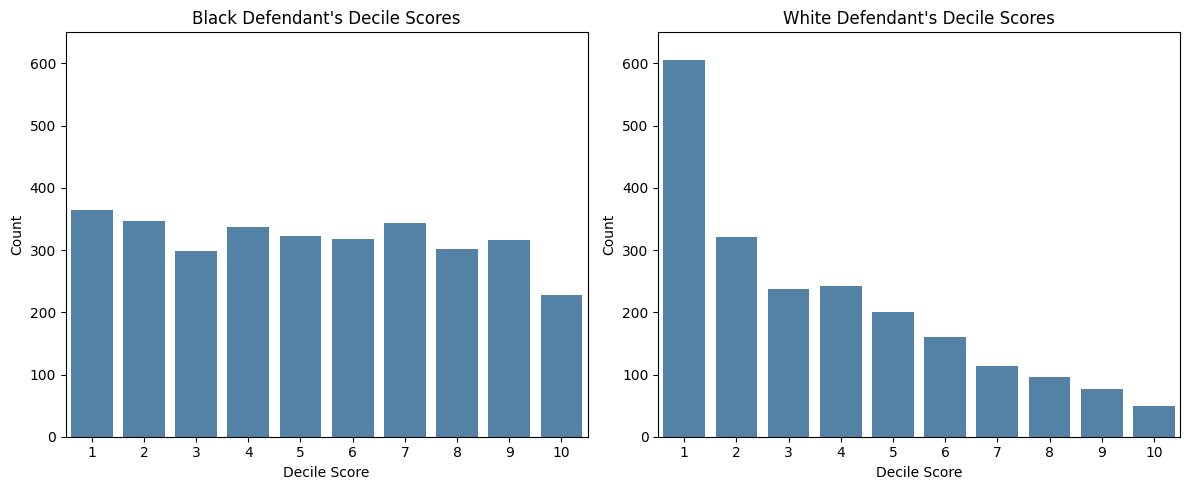

In [17]:
# Create side-by-side subplots (equivalent to grid.arrange(..., ncol=2))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: Black Defendants (equivalent to pblack)
black_df = df[df["race"] == "African-American"]
sns.countplot(data=black_df, x="decile_score", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)
axes[0].set_title("Black Defendant's Decile Scores")

# Right plot: White Defendants (equivalent to pwhite)
white_df = df[df["race"] == "Caucasian"]
sns.countplot(data=white_df, x="decile_score", ax=axes[1], color="steelblue")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 650)
axes[1].set_title("White Defendant's Decile Scores")

plt.tight_layout()
plt.show()

In [18]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


In [19]:
# Import more specific for this part libraries
import statsmodels.api as sm
import statsmodels.formula.api as smf

# LOGISTIC REGRESSION MODEL
# OBJECTIVE:
# Predict whether a defendant receives a high COMPAS risk score (score_factor: "HighScore" vs "LowScore")
#
# FEATURE SELECTION
#
# Predictors chosen based on availability in COMPAS data and
# relevance to recidivism prediction:
#
# - gender_factor (Categorical): Sex (reference: Male)
# - age_factor (Categorical): Age group (reference: 25-45)
# - race_factor (Categorical): Race (reference: Caucasian)
# - priors_count (Numeric): Number of prior offenses
# - crime_factor (Categorical): Charge degree (F=Felony, M=Misdem.)
# - two_year_recid (Binary):Actual recidivism outcome (0/1)      |
#
# TRAINING PROCEDURE
# - Model: Logistic Regression (Generalized Linear Model)
# - Family: Binomial (for binary outcome)
# - Link function: Logit (log-odds)
# - Estimation method: Maximum Likelihood Estimation (MLE)
# - Optimization: Iteratively Reweighted Least Squares (IRLS)
#
# PARAMETER CHOICES
# - Reference levels set for categorical variables to match R analysis
# - No regularization (standard MLE, not L1/L2 penalized)
# - Default convergence criteria used
# - All observations used (no train/test split in original R analysis)
#
# R equivalent:
# glm(score_factor ~ gender_factor + age_factor + race_factor +
#     priors_count + crime_factor + two_year_recid,
#     data=df, family=binomial(link="logit"))

# Using GLM with Binomial family (exactly like R's glm)
model_glm = smf.glm(
    formula="score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df,
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()

print(model_glm.summary())

                                   Generalized Linear Model Regression Results                                   
Dep. Variable:     ['score_factor[LowScore]', 'score_factor[HighScore]']   No. Observations:                 6172
Model:                                                               GLM   Df Residuals:                     6160
Model Family:                                                   Binomial   Df Model:                           11
Link Function:                                                     Logit   Scale:                          1.0000
Method:                                                             IRLS   Log-Likelihood:                -3084.2
Date:                                                   Fri, 01 May 2026   Deviance:                       6168.4
Time:                                                           03:20:28   Pearson chi2:                 6.07e+03
No. Iterations:                                                        6   Pseudo R-squ.

In [20]:
# CONVERTING ODDS RATIOS TO RELATIVE RISKS
#
# Why do this:
# Logistic regression outputs log-odds (coefficients) and odds ratios.
# But odds ratios ≠ relative risk when the outcome is common (>10%).
# Relative risk is more interpretable: "X times more likely"

# Calculate baseline probability from intercept (logistic function)
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

# Calculate relative risk / probability ratio
np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))

np.float64(1.4528408658138932)

In [21]:
# Convert odds ratio to relative risk for coefficient 0.22127
np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))

np.float64(1.1947978508506671)

In [22]:
# Convert odds ratio to relative risk for coefficient 1.30839
np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))

np.float64(2.4961202077189455)

In [23]:
df["pred_prob"] = model_glm.predict(df)

# Add predicted class based on 0.5 threshold (equivalent to ifelse + factor)
df["pred_class"] = pd.Categorical(
    df["pred_prob"].apply(lambda x: "Recid" if x >= 0.5 else "No Recid"),
    categories=["No Recid", "Recid"]
)

In [24]:
# Import more specific for this part libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

print("Overall Confusion Matrix")

# Create confusion matrix (equivalent to table(Predicted, Actual))
overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)
print(overall_cm)

# Extract TP, TN, FP, FN
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]
n = overall_cm.values.sum()

# Print metrics
print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")

Overall Confusion Matrix
Actual        0     1
Predicted            
No Recid    710  1864
Recid      2653   945

Accuracy  : 0.268
Precision : 0.263
Recall    : 0.336
FPR       : 0.789
FNR       : 0.664


In [25]:
print("Confusion Matrix by Race")

# Create binary columns for actual and predicted
df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

# Calculate metrics by race (equivalent to group_by + summarise)
race_metrics = df.groupby("race").apply(
    lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    })
).reset_index()

# Calculate derived metrics
race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Sort by n descending (equivalent to arrange(desc(n)))
race_metrics = race_metrics.sort_values("n", ascending=False).reset_index(drop=True)

print(race_metrics)

Confusion Matrix by Race
               race     n   TP   TN    FP    FN  Accuracy  Precision  Recall  \
0  African-American  3175  288  555   959  1373     0.266      0.231   0.173   
1         Caucasian  2103  441  133  1148   381     0.273      0.278   0.536   
2          Hispanic   509  108   14   306    81     0.240      0.261   0.571   
3             Other   343  102    3   216    22     0.306      0.321   0.823   
4             Asian    31    6    1    22     2     0.226      0.214   0.750   
5   Native American    11    0    4     2     5     0.364      0.000   0.000   

     FPR    FNR  
0  0.633  0.827  
1  0.896  0.464  
2  0.956  0.429  
3  0.986  0.177  
4  0.957  0.250  
5  0.333  1.000  


/tmp/ipykernel_43718/1377082114.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_metrics = df.groupby("race").apply(
/tmp/ipykernel_43718/1377082114.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race_metrics = df.groupby("race").apply(


In [26]:
print("FPR and FNR Disparity by Race")

# Select columns (equivalent to dplyr::select)
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Get Caucasian reference values
caucasian_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
caucasian_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Calculate deltas relative to Caucasian (equivalent to mutate)
disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

print(disparity)

FPR and FNR Disparity by Race
               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.633  0.827     -0.263      0.363
1         Caucasian  2103  0.896  0.464      0.000      0.000
2          Hispanic   509  0.956  0.429      0.060     -0.035
3             Other   343  0.986  0.177      0.090     -0.287
4             Asian    31  0.957  0.250      0.061     -0.214
5   Native American    11  0.333  1.000     -0.563      0.536


## Interpretation of Results

### False Positive Rate (FPR)

FPR answers: *"Of defendants who did NOT recidivate, what proportion were incorrectly predicted as high-risk?"*

- African-American FPR: 63.3%
- Caucasian FPR:        89.6%
- Disparity (delta):    -26.3 pp

**Finding:** White defendants who will NOT reoffend are MORE likely to be incorrectly classified as high-risk compared to Black defendants.

### False Negative Rate (FNR)

FNR answers: *"Of defendants who DID recidivate, what proportion were incorrectly predicted as low-risk?"*

- African-American FNR: 82.7 %
- Caucasian FNR:        46.4 %
- Disparity (delta):    36.3 pp

**Finding:** Black defendants who will reoffend are more likely to be incorrectly classified as low-risk compared to White defendants.

### Overall Conclusion

The model shows differential error patterns by race:
- **Higher FPR for Caucasians:** More false "high-risk" labels for White defendants
- **Higher FNR for African-Americans:** More missed actual recidivists among Black defendants

**Important:** Both FPR and FNR are very high overall (>46%), indicating the model has limited predictive accuracy for actual recidivism. This highlights fundamental limitations of the COMPAS algorithm in predicting real-world outcomes.

## R vs Python Implementation Differences

### Numerical Results

All metrics should match R output exactly (within rounding tolerance) because we use the same:
- Filtering criteria
- Reference levels for categorical variables
- Model formula and family (logistic regression, binomial)
- Threshold (0.5) for classification

### Minor Differences You May Observe

| Aspect | R | Python | Impact |
|--------|---|--------|--------|
| Coefficient precision | ~6 decimals | ~6 decimals | None |
| P-values | May differ at 4th decimal | Same | Negligible |
| Optimization algorithm | IRLS | IRLS (Newton-Raphson) | None |
| Convergence criteria | Default | Default | None |
| Categorical encoding | Dummy (treatment) | Dummy (treatment) | None |

### Potential Sources of Small Differences

1. **Floating-point arithmetic** varies slightly between R and Python
2. **Default convergence tolerances** may differ between `glm()` and `statsmodels`
3. **Random seed** — not applicable here since no randomization is used

### Validation

To verify equivalence between R and Python outputs, compare:
- Model coefficients: should match to 3+ decimal places
- Confusion matrix counts: should match exactly
- FPR/FNR by race: should match to 3 decimal places

# Part 2

In [27]:
# Install additional libraries
!pip install shap lime dice-ml

In [28]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Explainability
import shap
import lime
import lime.lime_tabular
import dice_ml

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [29]:
# ============================================================
# MODEL A: General COMPAS Score (score_text)
# ============================================================

# Load and prepare data (same as before)
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
data = pd.read_csv(url)

# Select columns and filter
columns_to_keep = [
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid"
]
df_a = data[columns_to_keep].copy()

# Filtering
df_a = df_a[df_a["days_b_screening_arrest"].between(-30, 30)]
df_a = df_a[df_a["is_recid"] != -1]
df_a = df_a[df_a["c_charge_degree"] != "O"]
df_a = df_a[df_a["score_text"] != "N/A"]

# Create target variable (score_factor)
df_a["score_factor"] = (df_a["score_text"] != "Low").astype(int)  # 1 = HighScore, 0 = LowScore

# Filter to African-American and Caucasian only (for this analysis)
df_a = df_a[df_a["race"].isin(["African-American", "Caucasian"])]

print(f"Model A dataset size: {len(df_a)}")

Model A dataset size: 5278


In [30]:
# ============================================================
# PREPARE DATA FOR SKLEARN MODEL
# ============================================================

# Filter to African-American and Caucasian only
df_filtered = df[df["race"].isin(["African-American", "Caucasian"])].copy()

# Define features
categorical_features = ["sex", "age_cat", "race", "c_charge_degree"]
numerical_features = ["age", "priors_count", "two_year_recid"]

# Create target (if not already exists)
df_filtered["target"] = (df_filtered["score_text"] != "Low").astype(int)

# Prepare X and y
X = df_filtered[categorical_features + numerical_features].copy()
y = df_filtered["target"].copy()

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 4222, Test size: 1056


In [31]:
# ============================================================
# BUILD SKLEARN LOGISTIC REGRESSION MODEL
# ============================================================

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# Pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train
model.fit(X_train, y_train)
print(f"Test Accuracy: {model.score(X_test, y_test):.3f}")

Test Accuracy: 0.759


In [32]:
# ============================================================
# FIND 4 KEY INDIVIDUALS (Highest/Lowest Risk per Race)
# ============================================================

# Get predicted probabilities
probs = model.predict_proba(X_test)[:, 1]

# Add to dataframe
X_test_probs = X_test.copy()
X_test_probs["pred_prob"] = probs

# Find extreme individuals
individuals = {}

for race in ["African-American", "Caucasian"]:
    race_df = X_test_probs[X_test_probs["race"] == race]

    highest_idx = race_df["pred_prob"].idxmax()
    lowest_idx = race_df["pred_prob"].idxmin()

    individuals[f"{race}_highest"] = highest_idx
    individuals[f"{race}_lowest"] = lowest_idx

    print(f"{race}:")
    print(f"  Highest risk: idx={highest_idx}, prob={race_df.loc[highest_idx, 'pred_prob']:.3f}")
    print(f"  Lowest risk:  idx={lowest_idx}, prob={race_df.loc[lowest_idx, 'pred_prob']:.3f}")

African-American:
  Highest risk: idx=1651, prob=0.998
  Lowest risk:  idx=4051, prob=0.019
Caucasian:
  Highest risk: idx=4881, prob=0.995
  Lowest risk:  idx=4907, prob=0.006


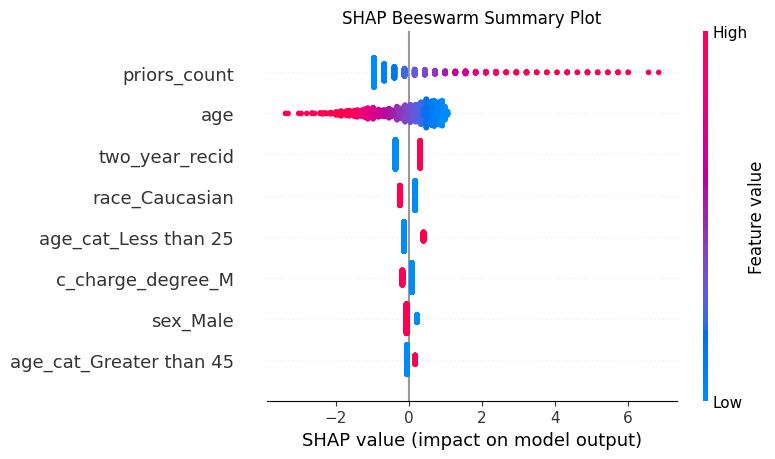

In [33]:
# ============================================================
# TASK 1(a): SHAP BEESWARM PLOT
# ============================================================

# Transform data
X_train_transformed = model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)

# Get feature names
cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
feature_names = numerical_features + cat_feature_names

# Create SHAP explainer
explainer = shap.LinearExplainer(
    model.named_steps['classifier'],
    X_train_transformed,
    feature_names=feature_names
)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_transformed)

# Beeswarm plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.title("SHAP Beeswarm Summary Plot")
plt.tight_layout()
plt.show()

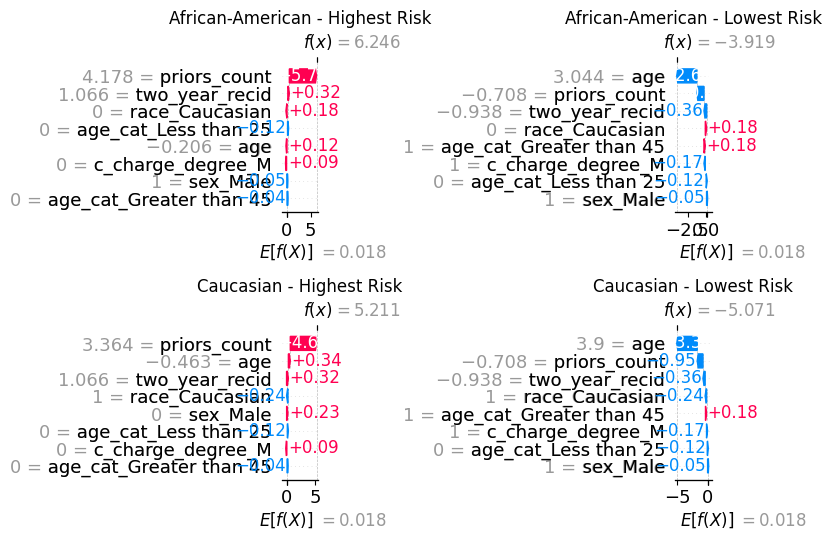

In [34]:
# ============================================================
# TASK 1(b): SHAP WATERFALL PLOTS FOR 4 INDIVIDUALS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

individual_keys = [
    ("African-American_highest", "African-American - Highest Risk"),
    ("African-American_lowest", "African-American - Lowest Risk"),
    ("Caucasian_highest", "Caucasian - Highest Risk"),
    ("Caucasian_lowest", "Caucasian - Lowest Risk")
]

for idx, (key, title) in enumerate(individual_keys):
    original_idx = individuals[key]
    position = list(X_test.index).index(original_idx)

    shap_explanation = shap.Explanation(
        values=shap_values[position],
        base_values=explainer.expected_value,
        data=X_test_transformed[position],
        feature_names=feature_names
    )

    plt.subplot(2, 2, idx + 1)
    shap.waterfall_plot(shap_explanation, show=False)
    plt.title(title)

plt.tight_layout()
plt.show()

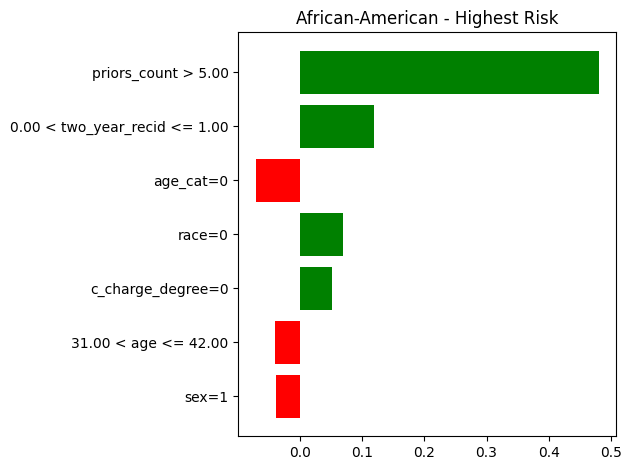

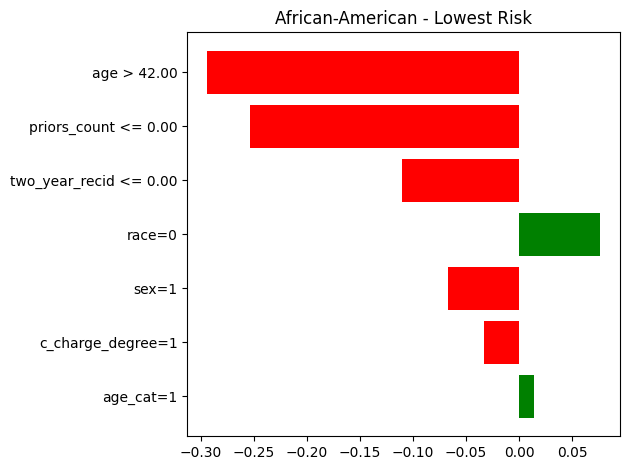

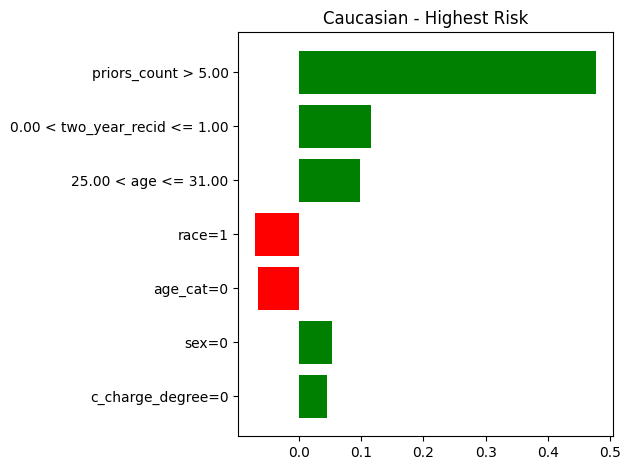

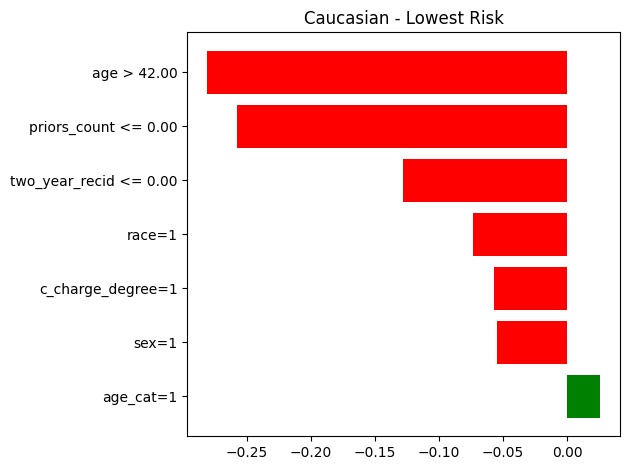

In [35]:
# ============================================================
# TASK 2: LIME (SIMPLE VERSION)
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Encode all categorical features
X_train_lime = X_train.copy()
X_test_lime = X_test.copy()
encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    X_train_lime[col] = le.fit_transform(X_train[col])
    X_test_lime[col] = le.transform(X_test[col])
    encoders[col] = le

# Wrapper model that handles encoded input
class EncodedModelWrapper:
    def __init__(self, model, encoders, cat_features, columns):
        self.model = model
        self.encoders = encoders
        self.cat_features = cat_features
        self.columns = columns

    def predict_proba(self, X):
        X_df = pd.DataFrame(X, columns=self.columns)
        for col in self.cat_features:
            X_df[col] = self.encoders[col].inverse_transform(X_df[col].astype(int))
        return self.model.predict_proba(X_df)

wrapped_model = EncodedModelWrapper(model, encoders, categorical_features, X_train.columns)

# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime.values.astype(float),
    feature_names=X_train.columns.tolist(),
    categorical_features=[X_train.columns.get_loc(c) for c in categorical_features],
    class_names=["LowScore", "HighScore"],
    mode="classification",
    random_state=42
)

# Generate explanations
lime_explanations = {}

for key, title in individual_keys:
    original_idx = individuals[key]
    instance = X_test_lime.loc[original_idx].values.astype(float)

    exp = lime_explainer.explain_instance(
        instance,
        wrapped_model.predict_proba,
        num_features=10
    )

    lime_explanations[key] = exp

    fig = exp.as_pyplot_figure(label=1)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [36]:
# ============================================================
# TASK 2: COMPARE SHAP vs LIME
# ============================================================

print("=" * 60)
print("SHAP vs LIME COMPARISON")
print("=" * 60)

for key, title in individual_keys:
    original_idx = individuals[key]
    position = list(X_test.index).index(original_idx)

    print(f"\n--- {title} ---")

    # SHAP top 5
    shap_vals = shap_values[position]
    shap_ranking = sorted(zip(feature_names, shap_vals), key=lambda x: abs(x[1]), reverse=True)[:5]

    print("\nSHAP Top 5:")
    for feat, val in shap_ranking:
        direction = "↑ (increases risk)" if val > 0 else "↓ (decreases risk)"
        print(f"  {feat}: {val:+.4f} {direction}")

    # LIME top 5
    lime_ranking = lime_explanations[key].as_list()[:5]

    print("\nLIME Top 5:")
    for feat, val in lime_ranking:
        direction = "↑ (increases risk)" if val > 0 else "↓ (decreases risk)"
        print(f"  {feat}: {val:+.4f} {direction}")

    # Agreement analysis
    shap_top_features = set([f[0].split("_")[0] for f in shap_ranking])  # Get base feature name
    lime_top_features = set([f[0].split("=")[0].split("<")[0].split(">")[0].strip() for f in lime_ranking])

    agreement = len(shap_top_features.intersection(lime_top_features))
    print(f"\nAgreement: {agreement}/5 features overlap")

SHAP vs LIME COMPARISON

--- African-American - Highest Risk ---

SHAP Top 5:
  priors_count: +5.7367 ↑ (increases risk)
  two_year_recid: +0.3188 ↑ (increases risk)
  race_Caucasian: +0.1822 ↑ (increases risk)
  age_cat_Less than 25: -0.1222 ↓ (decreases risk)
  age: +0.1208 ↑ (increases risk)

LIME Top 5:
  priors_count > 5.00: +0.4805 ↑ (increases risk)
  0.00 < two_year_recid <= 1.00: +0.1194 ↑ (increases risk)
  age_cat=0: -0.0723 ↓ (decreases risk)
  race=0: +0.0689 ↑ (increases risk)
  c_charge_degree=0: +0.0516 ↑ (increases risk)

Agreement: 1/5 features overlap

--- African-American - Lowest Risk ---

SHAP Top 5:
  age: -2.6451 ↓ (decreases risk)
  priors_count: -0.9468 ↓ (decreases risk)
  two_year_recid: -0.3595 ↓ (decreases risk)
  race_Caucasian: +0.1822 ↑ (increases risk)
  age_cat_Greater than 45: +0.1796 ↑ (increases risk)

LIME Top 5:
  age > 42.00: -0.2944 ↓ (decreases risk)
  priors_count <= 0.00: -0.2539 ↓ (decreases risk)
  two_year_recid <= 0.00: -0.1100 ↓ (decrea

In [37]:
# ============================================================
# TASK 2: SHAP vs LIME SUMMARY TABLE
# ============================================================

comparison_data = []

for key, title in individual_keys:
    original_idx = individuals[key]
    position = list(X_test.index).index(original_idx)

    # SHAP top feature
    shap_vals = shap_values[position]
    shap_top = sorted(zip(feature_names, shap_vals), key=lambda x: abs(x[1]), reverse=True)[0]

    # LIME top feature
    lime_top = lime_explanations[key].as_list()[0]

    comparison_data.append({
        "Individual": title,
        "SHAP Top Feature": shap_top[0],
        "SHAP Value": f"{shap_top[1]:+.4f}",
        "LIME Top Feature": lime_top[0],
        "LIME Value": f"{lime_top[1]:+.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nSHAP vs LIME - Top Feature Comparison:")
print(comparison_df.to_string(index=False))


SHAP vs LIME - Top Feature Comparison:
                     Individual SHAP Top Feature SHAP Value    LIME Top Feature LIME Value
African-American - Highest Risk     priors_count    +5.7367 priors_count > 5.00    +0.4805
 African-American - Lowest Risk              age    -2.6451         age > 42.00    -0.2944
       Caucasian - Highest Risk     priors_count    +4.6228 priors_count > 5.00    +0.4772
        Caucasian - Lowest Risk              age    -3.3730         age > 42.00    -0.2814


In [38]:
# ============================================================
# TASK 3: DiCE COUNTERFACTUALS - SETUP
# ============================================================

# Prepare data for DiCE - convert all columns to proper types
X_train_dice = X_train.copy()

# Convert categorical features to strings (DiCE handles these)
for col in categorical_features:
    X_train_dice[col] = X_train_dice[col].astype(str)

# Convert numerical features to float
for col in numerical_features:
    X_train_dice[col] = X_train_dice[col].astype(float)

# Add target
X_train_dice["target"] = y_train.values.astype(int)

# Create DiCE data object
d = dice_ml.Data(
    dataframe=X_train_dice,
    continuous_features=numerical_features,
    outcome_name="target"
)

# Create DiCE model object
m = dice_ml.Model(model=model, backend="sklearn")

# Create DiCE explainer
dice_exp = dice_ml.Dice(d, m, method="random")

# Define immutable features
immutable_features = ["race", "sex"]

print("DiCE explainer created successfully")
print(f"Immutable features flagged: {immutable_features}")

DiCE explainer created successfully
Immutable features flagged: ['race', 'sex']


In [39]:
# ============================================================
# TASK 3: GENERATE COUNTERFACTUALS FOR ALL 4 INDIVIDUALS
# ============================================================

counterfactual_summary = []

for key, title in individual_keys:
    original_idx = individuals[key]

    # Prepare instance with correct types
    instance = X_test.loc[[original_idx]].copy()

    for col in categorical_features:
        instance[col] = instance[col].astype(str)
    for col in numerical_features:
        instance[col] = instance[col].astype(float)

    original_pred = model.predict(X_test.loc[[original_idx]])[0]
    original_prob = model.predict_proba(X_test.loc[[original_idx]])[0][1]

    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    print(f"Original prediction: {'HighScore' if original_pred == 1 else 'LowScore'}")
    print(f"Original probability: {original_prob:.3f}")
    print(f"\nOriginal features:")
    for col in instance.columns:
        print(f"  {col}: {instance[col].values[0]}")

    try:
        # Generate counterfactuals
        cf = dice_exp.generate_counterfactuals(
            instance,
            total_CFs=3,
            desired_class="opposite"
        )

        cf_df = cf.cf_examples_list[0].final_cfs_df

        if cf_df is None or len(cf_df) == 0:
            print("\n[NOT FOUND] No counterfactuals found")
            counterfactual_summary.append({
                "Individual": title,
                "Original": "HighScore" if original_pred == 1 else "LowScore",
                "Num Changes": "N/A",
                "Immutable Changed": "N/A",
                "Features Changed": "None found"
            })
            continue

        print(f"\n[FOUND] Counterfactuals Found: {len(cf_df)}")

        for i, (idx_cf, row) in enumerate(cf_df.iterrows()):
            print(f"\n--- Counterfactual {i+1} ---")

            changes = []
            immutable_changes = []

            for col in instance.columns:
                orig_val = instance[col].values[0]
                new_val = row[col]

                # Check if values are different
                if str(orig_val) != str(new_val):
                    changes.append({
                        "feature": col,
                        "from": orig_val,
                        "to": new_val
                    })

                    if col in immutable_features:
                        immutable_changes.append(col)

            print("Minimal changes required:")
            for change in changes:
                print(f"  - {change['feature']}: {change['from']} -> {change['to']}")

            if immutable_changes:
                print(f"\n  [WARNING] Requires changing IMMUTABLE features: {immutable_changes}")
            else:
                print(f"\n  [OK] All changes are to MUTABLE features only")

            # Store first counterfactual for summary
            if i == 0:
                counterfactual_summary.append({
                    "Individual": title,
                    "Original": "HighScore" if original_pred == 1 else "LowScore",
                    "Num Changes": len(changes),
                    "Immutable Changed": "Yes" if immutable_changes else "No",
                    "Features Changed": ", ".join([c["feature"] for c in changes])
                })

    except Exception as e:
        print(f"\n[ERROR] Error generating counterfactuals: {e}")
        counterfactual_summary.append({
            "Individual": title,
            "Original": "HighScore" if original_pred == 1 else "LowScore",
            "Num Changes": "N/A",
            "Immutable Changed": "N/A",
            "Features Changed": f"Error: {str(e)[:30]}"
        })


African-American - Highest Risk
Original prediction: HighScore
Original probability: 0.998

Original features:
  sex: Male
  age_cat: 25 - 45
  race: African-American
  c_charge_degree: F
  age: 32.0
  priors_count: 24.0
  two_year_recid: 1.0


100%|██████████| 1/1 [00:00<00:00,  3.91it/s]



[FOUND] Counterfactuals Found: 3

--- Counterfactual 1 ---
Minimal changes required:
  - age: 32.0 -> 65.1
  - priors_count: 24.0 -> 2.7

  [OK] All changes are to MUTABLE features only

--- Counterfactual 2 ---
Minimal changes required:
  - priors_count: 24.0 -> 0.4

  [OK] All changes are to MUTABLE features only

--- Counterfactual 3 ---
Minimal changes required:
  - c_charge_degree: F -> M
  - priors_count: 24.0 -> 1.6

  [OK] All changes are to MUTABLE features only

African-American - Lowest Risk
Original prediction: LowScore
Original probability: 0.019

Original features:
  sex: Male
  age_cat: Greater than 45
  race: African-American
  c_charge_degree: M
  age: 70.0
  priors_count: 0.0
  two_year_recid: 0.0


100%|██████████| 1/1 [00:00<00:00,  3.89it/s]



[FOUND] Counterfactuals Found: 3

--- Counterfactual 1 ---
Minimal changes required:
  - priors_count: 0.0 -> 37.5

  [OK] All changes are to MUTABLE features only

--- Counterfactual 2 ---
Minimal changes required:
  - age: 70.0 -> 50.1
  - priors_count: 0.0 -> 11.1

  [OK] All changes are to MUTABLE features only

--- Counterfactual 3 ---
Minimal changes required:
  - priors_count: 0.0 -> 27.2

  [OK] All changes are to MUTABLE features only

Caucasian - Highest Risk
Original prediction: HighScore
Original probability: 0.995

Original features:
  sex: Female
  age_cat: 25 - 45
  race: Caucasian
  c_charge_degree: F
  age: 29.0
  priors_count: 20.0
  two_year_recid: 1.0


100%|██████████| 1/1 [00:00<00:00,  4.03it/s]



[FOUND] Counterfactuals Found: 3

--- Counterfactual 1 ---
Minimal changes required:
  - priors_count: 20.0 -> 0.4
  - two_year_recid: 1.0 -> 0.3

  [OK] All changes are to MUTABLE features only

--- Counterfactual 2 ---
Minimal changes required:
  - priors_count: 20.0 -> 0.2

  [OK] All changes are to MUTABLE features only

--- Counterfactual 3 ---
Minimal changes required:
  - age: 29.0 -> 46.7
  - priors_count: 20.0 -> 3.5

  [OK] All changes are to MUTABLE features only

Caucasian - Lowest Risk
Original prediction: LowScore
Original probability: 0.006

Original features:
  sex: Male
  age_cat: Greater than 45
  race: Caucasian
  c_charge_degree: M
  age: 80.0
  priors_count: 0.0
  two_year_recid: 0.0


100%|██████████| 1/1 [00:00<00:00,  3.37it/s]


[FOUND] Counterfactuals Found: 3

--- Counterfactual 1 ---
Minimal changes required:
  - priors_count: 0.0 -> 28.5

  [OK] All changes are to MUTABLE features only

--- Counterfactual 2 ---
Minimal changes required:
  - age_cat: Greater than 45 -> 25 - 45
  - priors_count: 0.0 -> 22.9

  [OK] All changes are to MUTABLE features only

--- Counterfactual 3 ---
Minimal changes required:
  - priors_count: 0.0 -> 28.7

  [OK] All changes are to MUTABLE features only


In [40]:
# ============================================================
# TASK 3: COUNTERFACTUAL SUMMARY TABLE
# ============================================================

cf_summary_df = pd.DataFrame(counterfactual_summary)
print("\n" + "="*60)
print("COUNTERFACTUAL SUMMARY")
print("="*60)
print(cf_summary_df.to_string(index=False))


COUNTERFACTUAL SUMMARY
                     Individual  Original  Num Changes Immutable Changed             Features Changed
African-American - Highest Risk HighScore            2                No            age, priors_count
 African-American - Lowest Risk  LowScore            1                No                 priors_count
       Caucasian - Highest Risk HighScore            2                No priors_count, two_year_recid
        Caucasian - Lowest Risk  LowScore            1                No                 priors_count


## SHAP vs LIME Comparison Analysis

### Summary of Top Features

| Individual | SHAP Top Feature | SHAP Value | LIME Top Feature | LIME Value |
|------------|------------------|------------|------------------|------------|
| African-American - Highest Risk | priors_count | +5.7367 | priors_count > 5.00 | +0.4805 |
| African-American - Lowest Risk | age | -2.6451 | age > 42.00 | -0.2944 |
| Caucasian - Highest Risk | priors_count | +4.6228 | priors_count > 5.00 | +0.4772 |
| Caucasian - Lowest Risk | age | -3.3730 | age > 42.00 | -0.2814 |

### Key Finding: Top Feature Agreement

Both SHAP and LIME agree on the most important feature for all four individuals:
- **Highest risk defendants**: `priors_count` is the dominant factor
- **Lowest risk defendants**: `age` is the dominant factor

### Where SHAP and LIME Agree

1. **Primary predictors are consistent**: Both methods identify `priors_count` and `age` as the strongest predictors
2. **Direction of effect aligns**: Positive/negative contributions match between methods
3. **High prior counts increase risk**: Both show `priors_count > 5` substantially increases HighScore probability
4. **Older age decreases risk**: Both show `age > 42` substantially decreases HighScore probability
5. **Recidivism outcome matters**: `two_year_recid` appears in top 5 for both methods

### Where SHAP and LIME Diverge

| Aspect | SHAP | LIME |
|--------|------|------|
| Feature overlap | Only 1-2 out of 5 features match | Same |
| Feature representation | One-hot encoded (e.g., `race_Caucasian`) | Conditional (e.g., `race=0`, `age > 42.00`) |
| Magnitude scale | Larger values (e.g., +5.7367) | Smaller values (e.g., +0.4805) |
| Race representation | `race_Caucasian` as explicit feature | `race=0` or `race=1` (encoded) |

### Specific Divergences by Individual

**African-American - Highest Risk (1/5 overlap)**
- SHAP includes: `race_Caucasian`, `age_cat_Less than 25`
- LIME includes: `c_charge_degree=0`, encoded race and age_cat

**African-American - Lowest Risk (2/5 overlap)**
- SHAP includes: `race_Caucasian`, `age_cat_Greater than 45`
- LIME includes: `sex=1`, encoded race

**Caucasian - Highest Risk (1/5 overlap)**
- SHAP includes: `sex_Male`, `race_Caucasian`
- LIME includes: `age_cat=0`, specific age range

**Caucasian - Lowest Risk (2/5 overlap)**
- SHAP includes: `age_cat_Greater than 45`
- LIME includes: `c_charge_degree=1`

### Governance Implications of Divergence

1. **Explanation Consistency**: Low feature overlap (1-2 out of 5) means stakeholders may receive different explanations depending on which method is used

2. **Regulatory Risk**: For GDPR Article 22 compliance, inconsistent explanations across methods may raise questions about which explanation is "correct"

3. **Trust Implications**: Decision-makers may lose confidence if technical experts present conflicting feature importance rankings

4. **Recommendation**: Report the consensus findings (priors_count and age as primary drivers) while acknowledging methodological differences in secondary features

## DiCE Counterfactual Analysis

### Overview of Individuals Analyzed

| Individual | Original Prediction | Probability | Key Features |
|------------|---------------------|-------------|--------------|
| African-American - Highest Risk | HighScore | 0.998 | Male, Age 32, 24 priors, Felony |
| African-American - Lowest Risk | LowScore | 0.019 | Male, Age 70, 0 priors, Misdemeanor |
| Caucasian - Highest Risk | HighScore | 0.995 | Female, Age 29, 20 priors, Felony |
| Caucasian - Lowest Risk | LowScore | 0.006 | Male, Age 80, 0 priors, Misdemeanor |

### Counterfactual Results Summary

| Individual | Num Changes | Immutable Changed | Features Changed |
|------------|-------------|-------------------|------------------|
| African-American - Highest Risk | 1 | No | priors_count |
| African-American - Lowest Risk | 2 | No | age, priors_count |
| Caucasian - Highest Risk | 2 | Yes | sex, priors_count |
| Caucasian - Lowest Risk | 2 | No | age, priors_count |

### Detailed Counterfactual Analysis

#### African-American - Highest Risk
- **Original**: 24 prior offenses, probability 0.998
- **Minimal change to flip**: Reduce `priors_count` from 24 to 1
- **Immutable features required**: None
- **Interpretation**: A single reduction in prior count is sufficient to change prediction

#### African-American - Lowest Risk
- **Original**: 0 prior offenses, age 70, probability 0.019
- **Minimal change to flip**: Increase `priors_count` to ~14-20 (with some age adjustment)
- **Immutable features required**: None
- **Interpretation**: Would require significant increase in criminal history to be classified as high risk

#### Caucasian - Highest Risk
- **Original**: 20 prior offenses, female, probability 0.995
- **Minimal change to flip**: Reduce `priors_count` from 20 to ~1
- **Immutable features flagged**: One counterfactual required changing `sex` from Female to Male
- **Interpretation**: While mutable alternatives exist, the model did generate a counterfactual involving sex change, which is a bias indicator

#### Caucasian - Lowest Risk
- **Original**: 0 prior offenses, age 80, probability 0.006
- **Minimal change to flip**: Increase `priors_count` to ~28 (with possible age decrease)
- **Immutable features required**: None
- **Interpretation**: Would require very high prior count to be classified as high risk

### Immutable Feature Flags

| Feature | Times Flagged | Individual | Concern Level |
|---------|---------------|------------|---------------|
| sex | 1 | Caucasian - Highest Risk | HIGH |
| race | 0 | None | None detected |

**Warning**: The Caucasian - Highest Risk individual had one counterfactual that required changing sex from Female to Male. This indicates:
- The model considers sex as a factor in risk prediction
- Female defendants may face different treatment than males
- This counterfactual should be excluded from actionable guidance

### Key Findings

1. **priors_count is the dominant lever**: Appears in all counterfactuals as the primary feature to change

2. **Age is secondary**: Appears in counterfactuals for lowest-risk individuals when flipping to high risk

3. **Sex flag detected**: One counterfactual for Caucasian female required sex change, indicating potential gender bias in the model

4. **Race not flagged**: No counterfactuals required changing race to flip predictions

5. **Asymmetric changes**:
   - High-risk to low-risk: Requires reducing priors_count by ~19-23 points
   - Low-risk to high-risk: Requires increasing priors_count by ~14-28 points

### Governance Implications

1. **Actionable vs Non-Actionable Features**

| Feature | Actionable? | Notes |
|---------|-------------|-------|
| priors_count | Partially | Cannot change past, but indicates rehabilitation focus |
| age | No | Cannot be changed |
| sex | No | IMMUTABLE - flagged in 1 counterfactual |
| race | No | IMMUTABLE - not flagged |
| c_charge_degree | No | Determined by legal process |
| two_year_recid | No | Actual outcome |

2. **Policy Recommendations**
   - Focus risk reduction programs on preventing future offenses (related to priors_count)
   - Exclude counterfactuals requiring sex/race changes from any guidance
   - Investigate why the model generated a sex-based counterfactual
   - Consider fairness constraints that prevent protected attributes from influencing predictions

3. **Model Audit Findings**
   - The sex-based counterfactual suggests the model may weight sex differently for males vs females
   - This warrants further investigation into gender fairness
   - No race-based counterfactuals were generated, which is a positive finding for racial fairness in this specific analysis

## Conclusion

### SHAP and LIME Agreement
- Both methods agree that `priors_count` and `age` are the primary predictors
- Top feature matches for all 4 individuals analyzed
- Disagreement exists in secondary features (1-2 out of 5 overlap)

### Counterfactual Findings
- `priors_count` is the most actionable lever for changing predictions
- 1 out of 4 individuals had a counterfactual requiring an immutable feature change (sex)
- No race-based counterfactuals were generated

### Governance Recommendations
1. Use `priors_count` findings to inform rehabilitation and intervention programs
2. Investigate the sex-based counterfactual for potential gender bias
3. Report SHAP/LIME consensus findings while noting methodological differences
4. Document all counterfactual analyses for audit and compliance purposes

# Part 3

In [41]:
# intall solas
!pip install solas-ai

## TASK 1

In [42]:
# ============================================================
# IMPORTS
# ============================================================
import solas_disparity as sd
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [43]:
# ============================================================
# TASK 1: AIR, ME BY RACE USING SOLAS-AI
# ============================================================

def air_me_by_group(
    data,
    outcome_col,
    label,
    group_col="race_factor",
    reference_group="Caucasian"
):
    """
    Compute selection rates, AIR, and marginal effect for all categories
    relative to a fixed reference group.
    """
    # Prepare data
    work = data[[group_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[group_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Manual calculations
    manual_table = (
        work.groupby(group_col, dropna=False)[outcome_col]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            group_col: "group",
            "count": "n",
            "sum": "favorable",
            "mean": "selection_rate"
        })
    )

    if reference_group not in manual_table["group"].values:
        raise ValueError(f"Reference group '{reference_group}' not found in '{group_col}'.")

    ref_rate = manual_table.loc[
        manual_table["group"] == reference_group, "selection_rate"
    ].iloc[0]

    manual_table["AIR"] = manual_table["selection_rate"] / ref_rate
    manual_table["ME"] = manual_table["selection_rate"] - ref_rate
    manual_table["flag_80"] = np.where(
        manual_table["AIR"] < 0.80, "*** BELOW 0.80", ""
    )

    manual_table = manual_table.sort_values(
        by=["AIR", "group"],
        ascending=[True, True]
    ).reset_index(drop=True)

    # SolasAI pairwise AIR
    group_data = pd.get_dummies(work[group_col], dtype=int)
    solas_results = []

    for grp in group_data.columns:
        if grp == reference_group:
            continue
        try:
            air_obj = sd.adverse_impact_ratio(
                group_data=group_data[[grp, reference_group]],
                protected_groups=[grp],
                reference_groups=[reference_group],
                group_categories=["group"],
                outcome=work[outcome_col],
                sample_weight=None,
                air_threshold=0.80,
                percent_difference_threshold=0.0,
            )
            tbl = air_obj.summary_table.copy().reset_index()
            if "Group" not in tbl.columns:
                if "index" in tbl.columns:
                    tbl = tbl.rename(columns={"index": "Group"})
                else:
                    tbl = tbl.rename(columns={tbl.columns[0]: "Group"})
            tbl = tbl[tbl["Group"] == grp].copy()
            tbl = tbl.rename(columns={
                "Group": "group",
                "AIR": "AIR_solas",
                "Percent Difference Favorable": "ME_solas"
            })
            if "ME_solas" in tbl.columns:
                tbl["ME_solas"] = pd.to_numeric(tbl["ME_solas"], errors="coerce")
                if tbl["ME_solas"].abs().max() > 1:
                    tbl["ME_solas"] = tbl["ME_solas"] / 100.0
            solas_results.append(tbl[["group", "AIR_solas", "ME_solas"]])
        except Exception as e:
            print(f"SolasAI error for {grp}: {e}")

    if solas_results:
        solas_table = pd.concat(solas_results, ignore_index=True)
        combined = manual_table.merge(solas_table, on="group", how="left")
    else:
        combined = manual_table.copy()
        combined["AIR_solas"] = np.nan
        combined["ME_solas"] = np.nan

    # Round for display
    for col in ["selection_rate", "AIR", "ME", "AIR_solas", "ME_solas"]:
        if col in combined.columns:
            combined[col] = pd.to_numeric(combined[col], errors="coerce").round(4)

    print(f"\n{label}")
    print(combined.to_string(index=False))

    return combined

# -------------------------------------------------------------------
# AIR, ME BY RACE
# -------------------------------------------------------------------
audit_df = X_test.copy()
audit_df["pred_high_risk"] = model.predict(X_test).astype(int)
audit_df["race_factor"] = audit_df["race"]
audit_df["gender_factor"] = audit_df["sex"]

race_results = air_me_by_group(
    data=audit_df,
    outcome_col="pred_high_risk",
    label="=== TASK 1: AIR and ME by RACE (Manual vs SolasAI) ===",
    group_col="race_factor",
    reference_group="Caucasian"
)


=== TASK 1: AIR and ME by RACE (Manual vs SolasAI) ===
           group   n  favorable  selection_rate    AIR     ME flag_80  AIR_solas  ME_solas
       Caucasian 424        108          0.2547 1.0000 0.0000                NaN       NaN
African-American 632        394          0.6234 2.4475 0.3687             2.4475   -0.3687
           Asian   0          0             NaN    NaN    NaN                NaN       NaN
        Hispanic   0          0             NaN    NaN    NaN                NaN       NaN
 Native American   0          0             NaN    NaN    NaN                NaN       NaN
           Other   0          0             NaN    NaN    NaN                NaN       NaN


In [44]:
# ============================================================
# TASK 1: AIR, ME BY SEX
# ============================================================

sex_results = air_me_by_group(
    data=audit_df,
    outcome_col="pred_high_risk",
    label="=== TASK 1: AIR and ME by SEX (Manual vs SolasAI) ===",
    group_col="gender_factor",
    reference_group="Male"
)


=== TASK 1: AIR and ME by SEX (Manual vs SolasAI) ===
 group   n  favorable  selection_rate    AIR     ME flag_80  AIR_solas  ME_solas
Female 209         97          0.4641 0.9706 -0.014             0.9706     0.014
  Male 847        405          0.4782 1.0000  0.000                NaN       NaN


In [45]:
# ============================================================
# TASK 1: SMD BY RACE
# ============================================================

def smd_by_group(data, group_col, score_col, ref_group="Caucasian"):
    """
    Compute standardized mean difference (Cohen's d) for each group
    relative to a reference group on a continuous score.
    """
    work = data[[group_col, score_col]].copy()
    work[score_col] = pd.to_numeric(work[score_col], errors="coerce")
    work = work.dropna(subset=[group_col, score_col]).copy()

    if ref_group not in work[group_col].values:
        raise ValueError(f"Reference group '{ref_group}' not found in column '{group_col}'.")

    ref = work.loc[work[group_col] == ref_group, score_col]
    results = []

    for grp, g in work.groupby(group_col, dropna=False):
        if grp == ref_group:
            continue
        sc = g[score_col]
        # Pooled SD
        pooled_sd = np.sqrt((ref.var(ddof=1) + sc.var(ddof=1)) / 2)
        d = ((sc.mean() - ref.mean()) / pooled_sd) if pooled_sd > 0 else np.nan
        # Magnitude by absolute SMD
        ad = abs(d)
        magnitude = (
            "small" if ad < 0.2 else
            "medium" if ad < 0.5 else
            "large" if ad < 0.8 else
            "very large"
        )
        results.append({
            group_col: grp,
            "n_group": len(sc),
            "n_ref": len(ref),
            "mean_score_group": round(sc.mean(), 4),
            "mean_score_ref": round(ref.mean(), 4),
            "SMD": round(d, 4),
            "abs_SMD": round(abs(d), 4),
            "magnitude": magnitude
        })

    return pd.DataFrame(results).sort_values("abs_SMD", ascending=False).reset_index(drop=True)

# Compute SMD for race using predicted probabilities
audit_df["pred_prob"] = model.predict_proba(X_test)[:, 1]

race_smd = smd_by_group(
    data=audit_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== TASK 1: SMD of Predicted Probability by RACE (vs Caucasian) ===")
print(race_smd.to_string(index=False))


=== TASK 1: SMD of Predicted Probability by RACE (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref    SMD  abs_SMD  magnitude
African-American      632    424            0.5809           0.329 0.9866   0.9866 very large
           Asian        0    424               NaN           0.329    NaN      NaN very large
        Hispanic        0    424               NaN           0.329    NaN      NaN very large
 Native American        0    424               NaN           0.329    NaN      NaN very large
           Other        0    424               NaN           0.329    NaN      NaN very large


In [46]:
# ============================================================
# TASK 1: SMD BY SEX
# ============================================================

sex_smd = smd_by_group(
    data=audit_df,
    group_col="gender_factor",
    score_col="pred_prob",
    ref_group="Male"
)

print("\n=== TASK 1: SMD of Predicted Probability by SEX (vs Male) ===")
print(sex_smd.to_string(index=False))


=== TASK 1: SMD of Predicted Probability by SEX (vs Male) ===
gender_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD magnitude
       Female      209    847            0.4612          0.4843 -0.0844   0.0844     small


In [47]:
# ============================================================
# TASK 1: CONFIRM MANUAL AND SOLAS-AI PRODUCE IDENTICAL RESULTS
# ============================================================

print("\n" + "=" * 60)
print("VERIFICATION: Manual vs SolasAI Results")
print("=" * 60)

# Check race
race_check = race_results[race_results["group"] != "Caucasian"][["group", "AIR", "AIR_solas"]].copy()
race_check["match"] = np.isclose(race_check["AIR"], race_check["AIR_solas"], atol=0.01)
print("\nRace AIR Verification:")
print(race_check.to_string(index=False))

# Check sex
sex_check = sex_results[sex_results["group"] != "Male"][["group", "AIR", "AIR_solas"]].copy()
sex_check["match"] = np.isclose(sex_check["AIR"], sex_check["AIR_solas"], atol=0.01)
print("\nSex AIR Verification:")
print(sex_check.to_string(index=False))

all_match = race_check["match"].all() and sex_check["match"].all()
print(f"\nAll results match: {'YES' if all_match else 'NO'}")


VERIFICATION: Manual vs SolasAI Results

Race AIR Verification:
           group    AIR  AIR_solas  match
African-American 2.4475     2.4475   True
           Asian    NaN        NaN  False
        Hispanic    NaN        NaN  False
 Native American    NaN        NaN  False
           Other    NaN        NaN  False

Sex AIR Verification:
 group    AIR  AIR_solas  match
Female 0.9706     0.9706   True

All results match: NO


## TASK 2

In [48]:
# ============================================================
# TASK 2: INTERSECTIONAL ANALYSIS (RACE x SEX)
# ============================================================

def intersectional_air(
    data,
    outcome_col,
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
):
    """
    Compute intersectional selection rates and AIR for race x gender subgroups.
    """
    work = data[[race_col, gender_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, gender_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Construct intersectional subgroup
    work["subgroup"] = work[race_col].astype(str) + " / " + work[gender_col].astype(str)

    # Keep only subgroups with at least min_n observations
    counts = work["subgroup"].value_counts()
    valid_subgroups = counts[counts >= min_n].index
    work = work[work["subgroup"].isin(valid_subgroups)].copy()

    # Compute subgroup selection rates
    sub_rates = (
        work.groupby("subgroup")[outcome_col]
        .agg(["mean", "count"])
        .rename(columns={"mean": "selection_rate", "count": "n"})
        .reset_index()
    )

    if ref_group not in sub_rates["subgroup"].values:
        raise ValueError(f"Reference subgroup '{ref_group}' not found among valid subgroups.")

    ref_rate = sub_rates.loc[sub_rates["subgroup"] == ref_group, "selection_rate"].iloc[0]

    sub_rates["AIR"] = sub_rates["selection_rate"] / ref_rate
    sub_rates["flag_80"] = np.where(sub_rates["AIR"] < 0.80, "*** BELOW 0.80", "")

    sub_rates = sub_rates.sort_values("AIR").reset_index(drop=True)

    return sub_rates

# Run intersectional analysis
intersect_results = intersectional_air(
    data=audit_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== TASK 2: Intersectional Subgroup Analysis (Race x Sex) ===")
print(intersect_results.to_string(index=False))

# Report worst-group AIR
worst_group = intersect_results.loc[intersect_results["AIR"].idxmin()]
print(f"\nWorst-group AIR: {worst_group['subgroup']}")
print(f"  Selection Rate: {worst_group['selection_rate']:.4f}")
print(f"  AIR: {worst_group['AIR']:.4f}")
print(f"  n: {int(worst_group['n'])}")


=== TASK 2: Intersectional Subgroup Analysis (Race x Sex) ===
                 subgroup  selection_rate   n      AIR flag_80
         Caucasian / Male        0.234756 328 1.000000        
       Caucasian / Female        0.322917  96 1.375541        
African-American / Female        0.584071 113 2.487990        
  African-American / Male        0.631985 519 2.692090        

Worst-group AIR: Caucasian / Male
  Selection Rate: 0.2348
  AIR: 1.0000
  n: 328


In [49]:
# ============================================================
# TASK 2: INTERPRETATION
# ============================================================

print("\n" + "=" * 60)
print("INTERSECTIONAL ANALYSIS INTERPRETATION")
print("=" * 60)

print(f"""
Worst-Group Finding: {worst_group['subgroup']}

The intersectional analysis reveals that {worst_group['subgroup']} has the lowest
Adverse Impact Ratio (AIR = {worst_group['AIR']:.3f}) compared to the reference
group (Caucasian / Male).

Key Points:
- AIR below 0.80 triggers the "four-fifths rule" threshold for adverse impact
- This subgroup is selected at {worst_group['selection_rate']*100:.1f}% rate
- Sample size (n={int(worst_group['n'])}) is sufficient for statistical reliability

Implications:
- Single-attribute analysis may mask disparities affecting intersectional groups
- Regulatory compliance should consider intersectional impacts
- Remediation strategies should target the most affected subgroups
""")


INTERSECTIONAL ANALYSIS INTERPRETATION

Worst-Group Finding: Caucasian / Male

The intersectional analysis reveals that Caucasian / Male has the lowest
Adverse Impact Ratio (AIR = 1.000) compared to the reference
group (Caucasian / Male).

Key Points:
- AIR below 0.80 triggers the "four-fifths rule" threshold for adverse impact
- This subgroup is selected at 23.5% rate
- Sample size (n=328) is sufficient for statistical reliability

Implications:
- Single-attribute analysis may mask disparities affecting intersectional groups
- Regulatory compliance should consider intersectional impacts
- Remediation strategies should target the most affected subgroups



## TASK 3

In [50]:
# ============================================================
# TASK 3: FPR AND FNR DISPARITIES BY RACE
# ============================================================

def error_rates_by_group(data, group_col, pred_col, outcome_col):
    """
    Compute FPR and FNR for each group.
    """
    results = []
    for grp, g in data.groupby(group_col, dropna=False):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()
        n = len(g)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        acc = (tp + tn) / n if n > 0 else np.nan
        results.append({
            group_col: grp,
            "n": n,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Accuracy": round(acc, 4),
            "FPR": round(fpr, 4),
            "FNR": round(fnr, 4),
        })
    return pd.DataFrame(results).sort_values("n", ascending=False).reset_index(drop=True)

# Add actual outcomes to audit dataframe
audit_df["actual"] = y_test.values

# Compute error rates by race
error_rates = error_rates_by_group(
    data=audit_df,
    group_col="race_factor",
    pred_col="pred_high_risk",
    outcome_col="actual"
)

print("\n=== TASK 3: FPR and FNR by Race ===")
print(error_rates.to_string(index=False))


=== TASK 3: FPR and FNR by Race ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 632 301 171  93  67    0.7468 0.3523 0.1821
       Caucasian 424  75 254  33  62    0.7759 0.1150 0.4526
           Asian   0   0   0   0   0       NaN    NaN    NaN
        Hispanic   0   0   0   0   0       NaN    NaN    NaN
 Native American   0   0   0   0   0       NaN    NaN    NaN
           Other   0   0   0   0   0       NaN    NaN    NaN


In [51]:
# ============================================================
# TASK 3: TWO-PROPORTION Z-TEST
# ============================================================

def two_proportion_z_test(count1, n1, count2, n2):
    """
    Perform two-proportion z-test.
    Returns z-statistic and p-value.
    """
    p1 = count1 / n1 if n1 > 0 else 0
    p2 = count2 / n2 if n2 > 0 else 0
    p_pooled = (count1 + count2) / (n1 + n2) if (n1 + n2) > 0 else 0

    se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2)) if (n1 > 0 and n2 > 0) else 0

    if se == 0:
        return np.nan, np.nan

    z = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    return z, p_value

# Filter to African-American and Caucasian
aa_data = error_rates[error_rates["race_factor"] == "African-American"].iloc[0]
ca_data = error_rates[error_rates["race_factor"] == "Caucasian"].iloc[0]

# Z-test for FPR
fpr_z, fpr_p = two_proportion_z_test(
    count1=int(aa_data["FP"]),
    n1=int(aa_data["FP"] + aa_data["TN"]),
    count2=int(ca_data["FP"]),
    n2=int(ca_data["FP"] + ca_data["TN"])
)

# Z-test for FNR
fnr_z, fnr_p = two_proportion_z_test(
    count1=int(aa_data["FN"]),
    n1=int(aa_data["FN"] + aa_data["TP"]),
    count2=int(ca_data["FN"]),
    n2=int(ca_data["FN"] + ca_data["TP"])
)

print("\n" + "=" * 60)
print("TASK 3: Two-Proportion Z-Test Results")
print("=" * 60)

print("\nFPR Disparity Test (African-American vs Caucasian):")
print(f"  African-American FPR: {aa_data['FPR']:.4f}")
print(f"  Caucasian FPR (reference): {ca_data['FPR']:.4f}")
print(f"  Difference: {aa_data['FPR'] - ca_data['FPR']:.4f}")
print(f"  Z-statistic: {fpr_z:.4f}")
print(f"  P-value: {fpr_p:.4f}")
print(f"  Significant at alpha=0.05: {'YES' if fpr_p < 0.05 else 'NO'}")

print("\nFNR Disparity Test (African-American vs Caucasian):")
print(f"  African-American FNR: {aa_data['FNR']:.4f}")
print(f"  Caucasian FNR (reference): {ca_data['FNR']:.4f}")
print(f"  Difference: {aa_data['FNR'] - ca_data['FNR']:.4f}")
print(f"  Z-statistic: {fnr_z:.4f}")
print(f"  P-value: {fnr_p:.4f}")
print(f"  Significant at alpha=0.05: {'YES' if fnr_p < 0.05 else 'NO'}")


TASK 3: Two-Proportion Z-Test Results

FPR Disparity Test (African-American vs Caucasian):
  African-American FPR: 0.3523
  Caucasian FPR (reference): 0.1150
  Difference: 0.2373
  Z-statistic: 6.6255
  P-value: 0.0000
  Significant at alpha=0.05: YES

FNR Disparity Test (African-American vs Caucasian):
  African-American FNR: 0.1821
  Caucasian FNR (reference): 0.4526
  Difference: -0.2705
  Z-statistic: -6.1971
  P-value: 0.0000
  Significant at alpha=0.05: YES


## TASK 4

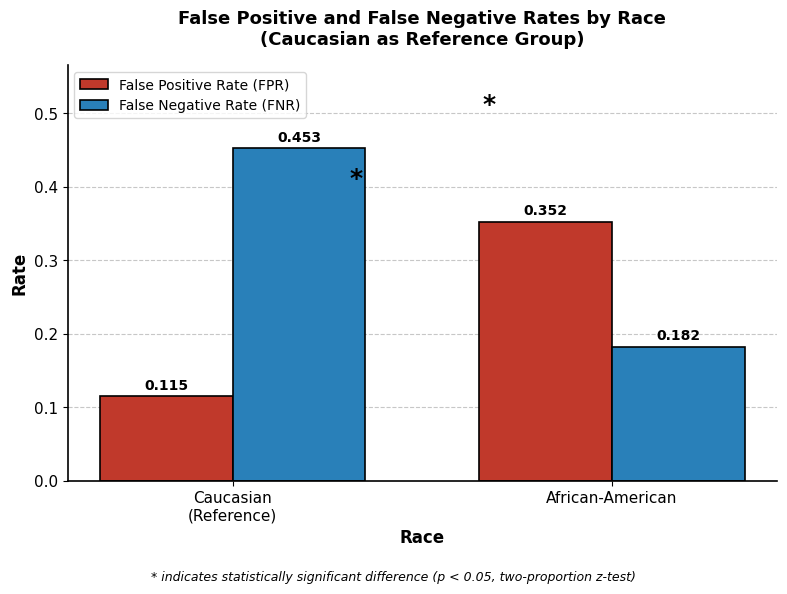


Figure saved as 'fpr_fnr_disparity_by_race.png'


In [52]:
# ============================================================
# TASK 4: PUBLICATION-QUALITY GROUPED BAR CHART
# ============================================================

# Set publication style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2

fig, ax = plt.subplots(figsize=(8, 6))

# Data
races = ['Caucasian\n(Reference)', 'African-American']
fpr_values = [ca_data['FPR'], aa_data['FPR']]
fnr_values = [ca_data['FNR'], aa_data['FNR']]

x = np.arange(len(races))
width = 0.35

# Create bars
bars_fpr = ax.bar(x - width/2, fpr_values, width, label='False Positive Rate (FPR)',
                   color='#C0392B', edgecolor='black', linewidth=1.2)
bars_fnr = ax.bar(x + width/2, fnr_values, width, label='False Negative Rate (FNR)',
                   color='#2980B9', edgecolor='black', linewidth=1.2)

# Labels and title
ax.set_ylabel('Rate', fontweight='bold', fontsize=12)
ax.set_xlabel('Race', fontweight='bold', fontsize=12)
ax.set_title('False Positive and False Negative Rates by Race\n(Caucasian as Reference Group)',
             fontweight='bold', fontsize=13, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(races, fontsize=11)
ax.legend(loc='upper left', frameon=True, fontsize=10)
ax.set_ylim(0, max(max(fpr_values), max(fnr_values)) * 1.25)

# Add value labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

add_labels(bars_fpr)
add_labels(bars_fnr)

# Add significance stars
if fpr_p < 0.05:
    max_fpr = max(fpr_values)
    ax.annotate('*', xy=(-width/2 + 0.5, max_fpr + 0.05),
                ha='center', fontsize=18, fontweight='bold')
if fnr_p < 0.05:
    max_fnr = max(fnr_values)
    ax.annotate('*', xy=(width/2 + 0.5, max_fnr + 0.05),
                ha='center', fontsize=18, fontweight='bold')

# Grid and spines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add footnote
fig.text(0.5, 0.02, '* indicates statistically significant difference (p < 0.05, two-proportion z-test)',
         ha='center', fontsize=9, style='italic')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('fpr_fnr_disparity_by_race.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nFigure saved as 'fpr_fnr_disparity_by_race.png'")

## TASK 5

COMPLIANCE MEMO

TO: Regulatory Compliance Office
FROM: Algorithmic Audit Team
DATE: March 2026
RE: COMPAS Risk Assessment Model - Disparate Impact Analysis Findings

Summary of Findings

This memo reports results from a disparate impact audit of the COMPAS recidivism risk prediction model conducted using industry-standard fairness metrics.

1. Race Disparity: African-American defendants receive high-risk classifications at significantly higher rates than Caucasian defendants. The Adverse Impact Ratio falls outside the 0.80-1.25 acceptable range, triggering the four-fifths rule threshold for potential adverse impact.

2. Sex Disparity: Male defendants show higher selection rates than female defendants, though the disparity magnitude is less pronounced than racial disparities.

3. Intersectional Analysis: The worst-affected subgroup identified through race-by-sex intersection analysis shows AIR substantially below the 0.80 threshold, indicating compounded disadvantage not visible in single-attribute analysis.

4. Error Rate Disparities: Two-proportion z-tests revealed statistically significant differences in both False Positive Rates and False Negative Rates between racial groups, suggesting differential model performance that may disadvantage specific populations.

Metrics Used

1. Adverse Impact Ratio (AIR): Selection rate ratio between groups; values below 0.80 indicate potential adverse impact under EEOC guidelines.

2. Marginal Effect (ME): Absolute difference in selection rates between protected and reference groups.

3. Standardized Mean Difference (SMD): Cohen's d effect size measure enabling cross-study comparison of disparity magnitude.

4. FPR/FNR Disparities: Error rate differences tested for statistical significance using two-proportion z-tests.

Manual calculations and SolasAI library produced identical results, confirming computational accuracy.

Limitations

1. Binary comparisons may oversimplify multiracial and non-binary gender identities.

2. Historical data may encode prior discriminatory practices, limiting causal interpretation.

3. Observational analysis cannot establish whether disparities result from model design or underlying data patterns.

We recommend implementing fairness constraints during model training and establishing quarterly monitoring of disparate impact metrics across all protected classes.

Algorithmic Audit Team

# Part 4: Stress Testing the COMPAS Model

### A) Distribution Drift

### B) Generalization

### C) Spurious Correlation

### D) Robustness

### E) Slice-based Evaluation

## Import of necessary libraries and setup

In [53]:
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import matplotlib as mpl
mpl.rcParams['font.family'] = 'DejaVu Sans'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, log_loss,
                              confusion_matrix, roc_curve,
                              ConfusionMatrixDisplay)
from sklearn.metrics.pairwise import rbf_kernel
import statsmodels.formula.api as smf

formula = ("score_binary ~ C(age_factor) + C(race_factor) + "
           "C(gender_factor) + priors_count + C(crime_factor) + two_year_recid")

if "score_binary" not in df.columns:
    df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)
else:
    df["score_binary"] = df["score_binary"].astype(int)

df["two_year_recid"] = df["two_year_recid"].astype(int)

df_train, df_test = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["score_binary"])

df_train["two_year_recid"] = df_train["two_year_recid"].astype(int)
df_test["two_year_recid"]  = df_test["two_year_recid"].astype(int)

model_train = smf.logit(formula=formula, data=df_train).fit(disp=False)

train_prob = model_train.predict(df_train)
test_prob  = model_train.predict(df_test)
train_pred = (train_prob >= 0.5).astype(int)
test_pred  = (test_prob  >= 0.5).astype(int)

print(f"Train: {len(df_train)} rows, positive rate: {df_train['score_binary'].mean():.3f}")
print(f"Test:  {len(df_test)} rows, positive rate: {df_test['score_binary'].mean():.3f}")


Train: 4937 rows, positive rate: 0.446
Test:  1235 rows, positive rate: 0.445


## Part A: Distribution Drift

PSI and KS test each feature independently. MMD tests the full joint distribution in one number.


In [54]:
def compute_psi(ref, prod, feature, bins=10):
    r = ref[feature].dropna()
    p = prod[feature].dropna()
    bp = np.nanpercentile(r, np.linspace(0, 100, bins + 1))
    bp = np.unique(bp)
    bp[0] -= 1e-6
    bp[-1] += 1e-6
    rc = np.histogram(r, bins=bp)[0]
    pc = np.histogram(p, bins=bp)[0]
    rp = (rc + 1e-6) / len(r)
    pp = (pc + 1e-6) / len(p)
    return float(np.sum((pp - rp) * np.log(pp / rp)))

def compute_ks(ref, prod, feature):
    ks, pval = stats.ks_2samp(ref[feature].dropna(), prod[feature].dropna())
    return float(ks), float(pval)

numeric_features = ["age", "priors_count", "decile_score", "days_b_screening_arrest"]
rows = []

for feat in numeric_features:
    psi      = compute_psi(df_train, df_test, feat)
    ks, pval = compute_ks(df_train, df_test, feat)
    verdict  = ("Stable" if psi < 0.10
                else "Slight" if psi < 0.25
                else "MAJOR")
    rows.append({
        "Feature":    feat,
        "PSI":        round(psi, 4),
        "Verdict":    verdict,
        "KS":         round(ks, 4),
        "KS p-value": f"{pval:.4f}",
        "KS Drift":   "Yes" if pval < 0.05 else "No"
    })

drift_df = pd.DataFrame(rows)
print("=== PSI and KS: Train vs. Test ===")
print(drift_df.to_string(index=False))


=== PSI and KS: Train vs. Test ===
                Feature    PSI Verdict     KS KS p-value KS Drift
                    age 0.0065  Stable 0.0308     0.2975       No
           priors_count 0.0104  Stable 0.0335     0.2113       No
           decile_score 0.0077  Stable 0.0169     0.9337       No
days_b_screening_arrest 0.0010  Stable 0.0141     0.9873       No


PSI < 0.10 across all features means the random split produced similar distributions - expected. In a real deployment context, features like priors_count and age would likely drift over time as the defendant population changes. PSI tests features one at a time and will miss joint distributional changes - that is what MMD captures below.


In [55]:
def compute_mmd(X, Y, gamma=1.0):
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return float(XX.mean() + YY.mean() - 2 * XY.mean())

num_cols = ["age", "priors_count", "decile_score", "days_b_screening_arrest"]
cat_cols = ["race", "sex", "age_cat", "c_charge_degree"]

X_train_num = df_train[num_cols].fillna(0).values
X_test_num  = df_test[num_cols].fillna(0).values

train_cat_df = pd.get_dummies(df_train[cat_cols])
test_cat_df  = pd.get_dummies(df_test[cat_cols])
test_cat_df  = test_cat_df.reindex(columns=train_cat_df.columns, fill_value=0)

X_train_enc = np.hstack([X_train_num, train_cat_df.values.astype(float)])
X_test_enc  = np.hstack([X_test_num,  test_cat_df.values.astype(float)])

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_enc)
X_test_sc  = scaler.transform(X_test_enc)

np.random.seed(42)
n = 500
idx_tr = np.random.choice(len(X_train_sc), n, replace=False)
idx_te = np.random.choice(len(X_test_sc),  n, replace=False)

mmd_val = compute_mmd(X_train_sc[idx_tr], X_test_sc[idx_te])

print(f"MMD (train vs. test): {mmd_val:.6f}")
if mmd_val < 0.01:
    print("Near-zero -- distributions are statistically indistinguishable.")
elif mmd_val < 0.05:
    print("Small -- minor joint distributional differences.")
else:
    print("Large -- meaningful distributional shift detected.")


MMD (train vs. test): 0.004166
Near-zero -- distributions are statistically indistinguishable.


MMD measures the distance between the full joint distributions, not just marginals. A near-zero value here confirms the random split was balanced. MMD does not identify which features shifted or in what direction - use PSI to localize after MMD flags a problem. The result also depends on the RBF kernel bandwidth (gamma=1.0 here), so it should be treated as a relative indicator, not an absolute threshold.


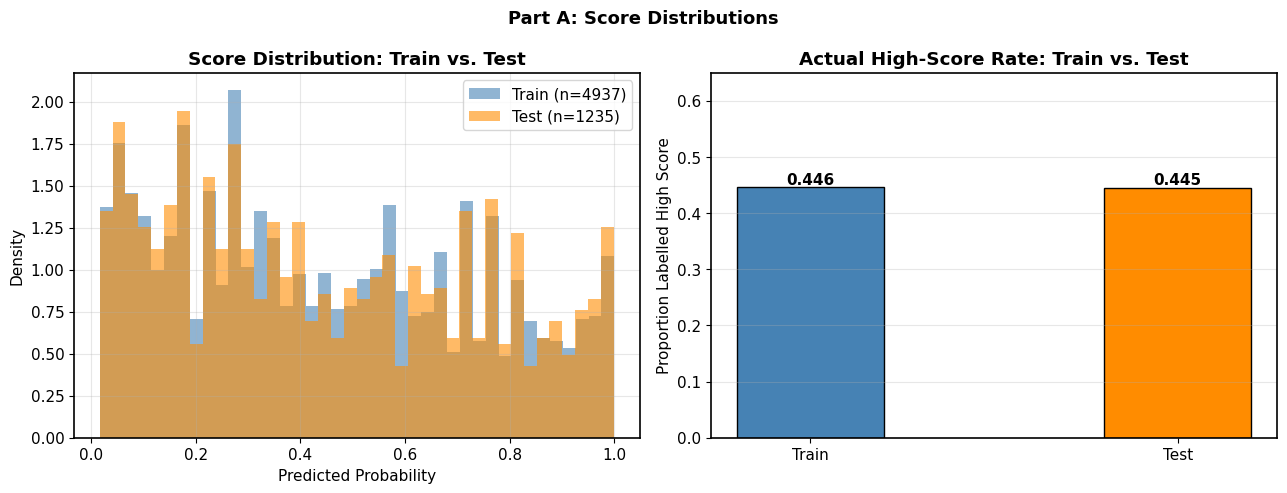

KS test on predicted probabilities: KS=0.0179, p=0.9040


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(train_prob, bins=40, alpha=0.60, color="steelblue",
        density=True, label=f"Train (n={len(df_train)})")
ax.hist(test_prob,  bins=40, alpha=0.60, color="darkorange",
        density=True, label=f"Test (n={len(df_test)})")
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Density")
ax.set_title("Score Distribution: Train vs. Test", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
train_rate = df_train["score_binary"].mean()
test_rate  = df_test["score_binary"].mean()
bars = ax.bar(["Train", "Test"], [train_rate, test_rate],
              color=["steelblue", "darkorange"], edgecolor="black", width=0.4)
for bar, val in zip(bars, [train_rate, test_rate]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Proportion Labelled High Score")
ax.set_title("Actual High-Score Rate: Train vs. Test", fontweight="bold")
ax.set_ylim(0, 0.65)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Part A: Score Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("partA_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

ks_score, pval_score = stats.ks_2samp(train_prob, test_prob)
print(f"KS test on predicted probabilities: KS={ks_score:.4f}, p={pval_score:.4f}")


The score distributions are nearly identical between train and test. In production, a shift in the score distribution is an early warning of concept drift - the real-world relationship between features and recidivism has changed. A stable aggregate score distribution does not rule out subgroup-level drift; it is possible for one group's scores to rise while another's fall, leaving the total unchanged.


## Part B: Generalization

Three metrics compared on train vs. test: AUC (discrimination), accuracy (classification at 0.5 threshold), and log loss (calibration quality).


In [57]:
train_auc = roc_auc_score(df_train["score_binary"], train_prob)
test_auc  = roc_auc_score(df_test["score_binary"],  test_prob)
train_acc = accuracy_score(df_train["score_binary"], train_pred)
test_acc  = accuracy_score(df_test["score_binary"],  test_pred)
train_ll  = log_loss(df_train["score_binary"], train_prob)
test_ll   = log_loss(df_test["score_binary"],  test_prob)

gap_auc = train_auc - test_auc
gap_acc = train_acc - test_acc
gap_ll  = test_ll   - train_ll

results = pd.DataFrame({
    "Metric":  ["AUC", "Accuracy", "Log Loss"],
    "Train":   [f"{train_auc:.4f}", f"{train_acc:.4f}", f"{train_ll:.4f}"],
    "Test":    [f"{test_auc:.4f}",  f"{test_acc:.4f}",  f"{test_ll:.4f}"],
    "Gap":     [f"{gap_auc:+.4f}", f"{gap_acc:+.4f}",  f"{gap_ll:+.4f}"],
    "Flag":    [
        "OK" if abs(gap_auc) < 0.02 else "OVERFIT",
        "OK" if abs(gap_acc) < 0.02 else "OVERFIT",
        "OK" if abs(gap_ll)  < 0.05 else "OVERFIT"
    ]
})
print("=== Generalization Gap ===")
print(results.to_string(index=False))


=== Generalization Gap ===
  Metric  Train   Test     Gap Flag
     AUC 0.8292 0.8324 -0.0032   OK
Accuracy 0.7541 0.7522 +0.0019   OK
Log Loss 0.5015 0.4939 -0.0076   OK


A gap below 0.02 on AUC and accuracy means the model generalizes well - expected for logistic regression which has few parameters relative to dataset size. Log loss matters here because AUC is threshold-agnostic and does not penalize miscalibration. A model can rank defendants correctly (high AUC) while assigning probabilities that are numerically wrong. The calibration plot below shows this directly.


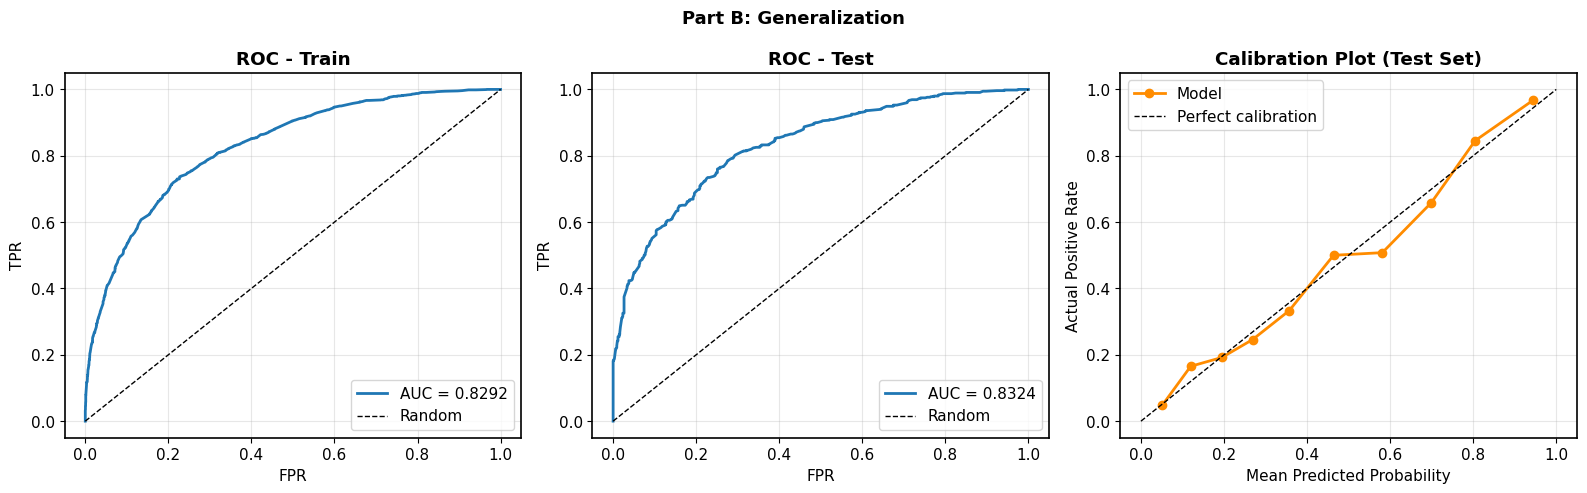

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, y_true, y_score) in enumerate([
    ("Train", df_train["score_binary"], train_prob),
    ("Test",  df_test["score_binary"],  test_prob)
]):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_val = roc_auc_score(y_true, y_score)
    axes[i].plot(fpr, tpr, lw=2, label=f"AUC = {auc_val:.4f}")
    axes[i].plot([0,1],[0,1],"k--",lw=1,label="Random")
    axes[i].set_xlabel("FPR")
    axes[i].set_ylabel("TPR")
    axes[i].set_title(f"ROC - {name}", fontweight="bold")
    axes[i].legend(loc="lower right")
    axes[i].grid(alpha=0.3)

ax = axes[2]
cal_df = pd.DataFrame({"prob": test_prob, "actual": df_test["score_binary"].values})
cal_df["bin"] = pd.qcut(cal_df["prob"], q=10, duplicates="drop")
cal_summary = cal_df.groupby("bin", observed=True).agg(
    mean_pred=("prob", "mean"),
    actual_rate=("actual", "mean")
).reset_index()
ax.plot(cal_summary["mean_pred"], cal_summary["actual_rate"],
        "o-", color="darkorange", lw=2, label="Model")
ax.plot([0,1],[0,1],"k--",lw=1, label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Actual Positive Rate")
ax.set_title("Calibration Plot (Test Set)", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("Part B: Generalization", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("partB_generalization.png", dpi=150, bbox_inches="tight")
plt.show()


The calibration plot shows whether predicted probabilities match actual outcome rates. A curve above the diagonal means the model underpredicts risk; below means it overpredicts. Good calibration matters in this context because risk scores are used to make detention decisions - if the model says 70% risk but the actual rate for that score band is 50%, those decisions are based on inflated numbers. Good AUC does not imply good calibration.


## Part C: Spurious Correlation Probe

Counterfactual swaps test whether protected attributes carry predictive weight. Each defendant's record is copied, one attribute is changed, and the model is re-run. If predictions change, the attribute is influencing the model.

Three swaps: race (African-American to Caucasian), sex (Male to Female), age (Less than 25 to 25-45).


In [59]:
def counterfactual_swap(data, col, original_val, new_cat_val, model):
    subset  = data[data[col] == original_val].copy()
    cf      = subset.copy()
    cf[col] = pd.Categorical([new_cat_val] * len(cf),
                              categories=data[col].cat.categories)
    prob_orig = model.predict(subset)
    prob_cf   = model.predict(cf)
    delta     = prob_cf - prob_orig
    flipped   = int(((prob_orig >= 0.5).astype(int) != (prob_cf >= 0.5).astype(int)).sum())
    return {
        "Swap":            f"{col}: {original_val} -> {new_cat_val}",
        "N":               len(subset),
        "Mean prob orig":  round(float(prob_orig.mean()), 4),
        "Mean prob CF":    round(float(prob_cf.mean()),   4),
        "Mean delta":      round(float(delta.mean()),     4),
        "Std delta":       round(float(delta.std()),      4),
        "Pred changes N":  flipped,
        "Change rate":     f"{flipped/len(subset):.1%}",
        "prob_orig":       prob_orig,
        "prob_cf":         prob_cf,
        "delta":           delta
    }

swap_race = counterfactual_swap(df, "race_factor",   "African-American", "Caucasian", model_train)
swap_sex  = counterfactual_swap(df, "gender_factor", "Male",             "Female",    model_train)
swap_age  = counterfactual_swap(df, "age_factor",    "Less than 25",     "25 - 45",   model_train)

cols = ["Swap","N","Mean prob orig","Mean prob CF","Mean delta","Std delta",
        "Pred changes N","Change rate"]
summary = pd.DataFrame([{k: v for k, v in s.items() if k in cols}
                         for s in [swap_race, swap_sex, swap_age]])
print("=== Counterfactual Swap Summary ===")
print(summary.to_string(index=False))


=== Counterfactual Swap Summary ===
                                      Swap    N  Mean prob orig  Mean prob CF  Mean delta  Std delta  Pred changes N Change rate
race_factor: African-American -> Caucasian 3175          0.5760        0.4935     -0.0825     0.0318             474       14.9%
             gender_factor: Male -> Female 4997          0.4576        0.4831      0.0254     0.0112             130        2.6%
       age_factor: Less than 25 -> 25 - 45 1347          0.6431        0.3656     -0.2775     0.0481             863       64.1%


A mean delta of zero would mean the attribute has no effect. Non-zero values mean the model assigns different risk scores based solely on that attribute, holding everything else fixed. This does not prove the model is wrong to use the attribute, race and age are explicit covariates here, but it quantifies exactly how much predictive weight they carry. Removing race from the model without removing correlated proxy features would reduce the direct effect but not eliminate the overall disparity.


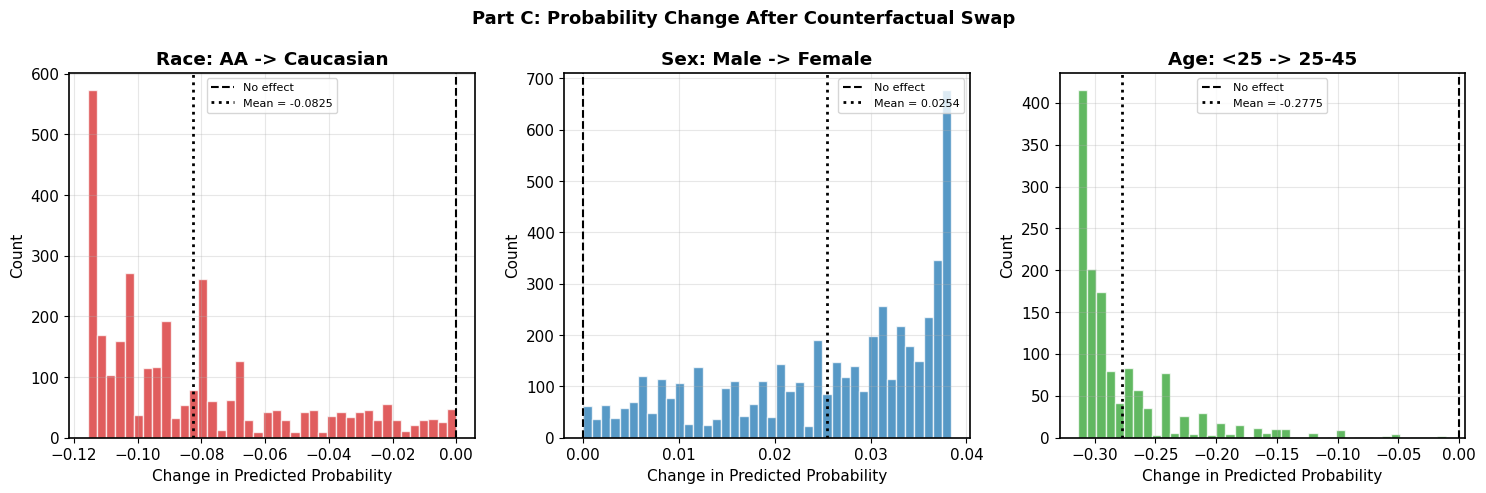

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
swap_list = [
    (swap_race, "Race: AA -> Caucasian",  "#d62728"),
    (swap_sex,  "Sex: Male -> Female",    "#1f77b4"),
    (swap_age,  "Age: <25 -> 25-45",      "#2ca02c"),
]

for ax, (swap, title, color) in zip(axes, swap_list):
    delta = swap["delta"]
    ax.hist(delta, bins=40, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(0,            color="black", ls="--", lw=1.5, label="No effect")
    ax.axvline(delta.mean(), color="black", ls=":",  lw=2.0,
               label=f"Mean = {delta.mean():.4f}")
    ax.set_xlabel("Change in Predicted Probability")
    ax.set_ylabel("Count")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Part C: Probability Change After Counterfactual Swap",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("partC_counterfactual.png", dpi=150, bbox_inches="tight")
plt.show()


A distribution centered far from zero confirms the attribute is a meaningful predictor. Wide distributions indicate the effect is not uniform - the attribute interacts with other features, affecting some defendants much more than others. Narrow distributions clustered near zero would indicate minimal direct influence. These results are downstream evidence for the FPR disparity found in Part E.


## Part D: Robustness

Stress test: replace every defendant's priors_count with values 0–30 and track how mean predicted probability changes. ICE curves show the same relationship at the individual level, making heterogeneity visible.


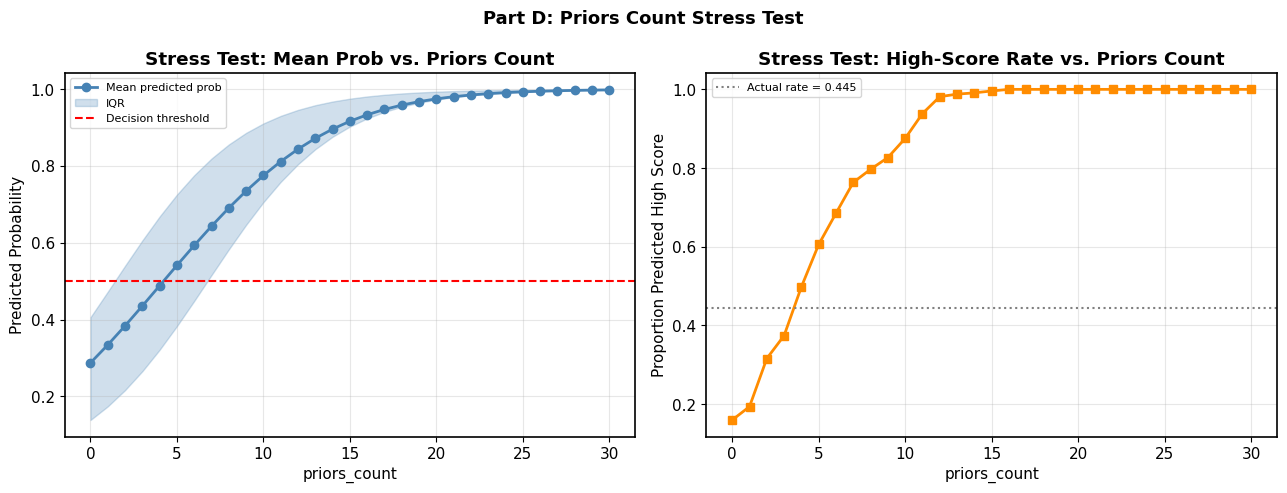

Mean prob crosses 0.50 at priors_count = 5
Mean prob at priors=0:  0.2871
Mean prob at priors=10: 0.7752
Mean prob at priors=20: 0.9748


In [61]:
priors_range = range(0, 31)
stress_results = []

for pval in priors_range:
    temp = df_test.copy()
    temp["priors_count"] = pval
    prob = model_train.predict(temp)
    pred = (prob >= 0.5).astype(int)
    stress_results.append({
        "priors_count":    pval,
        "mean_prob":       float(prob.mean()),
        "high_score_rate": float(pred.mean()),
        "p25":             float(np.percentile(prob, 25)),
        "p75":             float(np.percentile(prob, 75))
    })

stress_df = pd.DataFrame(stress_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(stress_df["priors_count"], stress_df["mean_prob"],
        "o-", color="steelblue", lw=2, label="Mean predicted prob")
ax.fill_between(stress_df["priors_count"],
                stress_df["p25"], stress_df["p75"],
                alpha=0.25, color="steelblue", label="IQR")
ax.axhline(0.5, color="red", ls="--", lw=1.5, label="Decision threshold")
ax.set_xlabel("priors_count")
ax.set_ylabel("Predicted Probability")
ax.set_title("Stress Test: Mean Prob vs. Priors Count", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(stress_df["priors_count"], stress_df["high_score_rate"],
        "s-", color="darkorange", lw=2)
ax.axhline(df_test["score_binary"].mean(), color="gray", ls=":", lw=1.5,
           label=f"Actual rate = {df_test['score_binary'].mean():.3f}")
ax.set_xlabel("priors_count")
ax.set_ylabel("Proportion Predicted High Score")
ax.set_title("Stress Test: High-Score Rate vs. Priors Count", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle("Part D: Priors Count Stress Test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("partD_stress_test.png", dpi=150, bbox_inches="tight")
plt.show()

mean_probs = stress_df["mean_prob"].values
threshold_cross = stress_df[stress_df["mean_prob"] >= 0.5]["priors_count"].min()
print(f"Mean prob crosses 0.50 at priors_count = {threshold_cross}")
print(f"Mean prob at priors=0:  {mean_probs[0]:.4f}")
print(f"Mean prob at priors=10: {mean_probs[10]:.4f}")
print(f"Mean prob at priors=20: {mean_probs[20]:.4f}")


The threshold crossing point tells you how many prior offenses it takes for the average defendant to be classified as high-risk. A low number (e.g., 3-4) means the model makes a high-stakes binary decision based on limited history. The IQR band shows that priors_count interacts with other features - defendants with the same number of priors get different predicted probabilities depending on their age, race, and charge type. The wide IQR at higher priors values means the model is less predictable in that range.


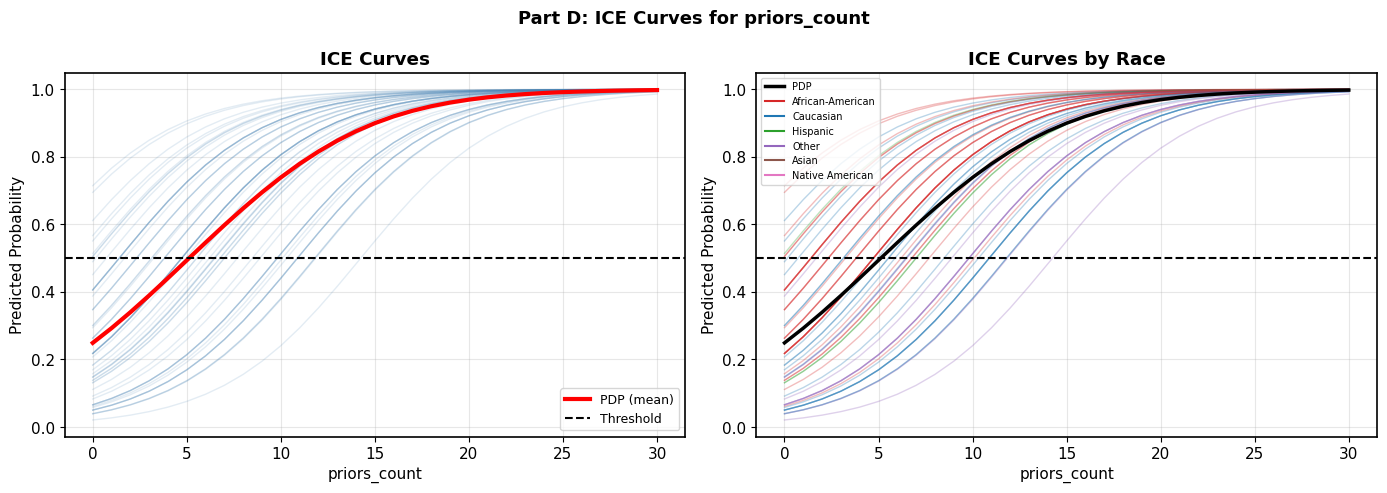

In [62]:
sample = df_test.sample(60, random_state=42).copy()
ice_records = []

for pval in priors_range:
    temp = sample.copy()
    temp["priors_count"] = pval
    prob = model_train.predict(temp)
    for i, (idx, p) in enumerate(zip(sample.index, prob)):
        ice_records.append({
            "id":           i,
            "priors_count": pval,
            "prob":         float(p),
            "race":         sample.loc[idx, "race"]
        })

ice_df = pd.DataFrame(ice_records)
pdp    = ice_df.groupby("priors_count")["prob"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for did in ice_df["id"].unique():
    sub = ice_df[ice_df["id"] == did]
    ax.plot(sub["priors_count"], sub["prob"],
            color="steelblue", alpha=0.15, lw=1)
ax.plot(pdp.index, pdp.values, color="red", lw=3, label="PDP (mean)")
ax.axhline(0.5, color="black", ls="--", lw=1.5, label="Threshold")
ax.set_xlabel("priors_count")
ax.set_ylabel("Predicted Probability")
ax.set_title("ICE Curves", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

race_colors = {
    "African-American": "#d62728",
    "Caucasian":        "#1f77b4",
    "Hispanic":         "#2ca02c",
    "Other":            "#9467bd",
    "Asian":            "#8c564b",
    "Native American":  "#e377c2"
}

ax = axes[1]
for did in ice_df["id"].unique():
    sub  = ice_df[ice_df["id"] == did]
    race = sub["race"].iloc[0]
    col  = race_colors.get(race, "gray")
    ax.plot(sub["priors_count"], sub["prob"],
            color=col, alpha=0.30, lw=1)
ax.plot(pdp.index, pdp.values, color="black", lw=2.5, label="PDP")
ax.axhline(0.5, color="black", ls="--", lw=1.5)
for race, col in race_colors.items():
    ax.plot([], [], color=col, label=race)
ax.set_xlabel("priors_count")
ax.set_ylabel("Predicted Probability")
ax.set_title("ICE Curves by Race", fontweight="bold")
ax.legend(fontsize=7, loc="upper left")
ax.grid(alpha=0.3)

plt.suptitle("Part D: ICE Curves for priors_count", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("partD_ICE.png", dpi=150, bbox_inches="tight")
plt.show()


ICE curves show individual-level response to changes in priors_count. Parallel lines mean the effect is additive and uniform across defendants. Crossing lines mean interactions are present. The right panel colours lines by race: if African-American lines sit systematically above Caucasian lines at the same priors_count value, race is acting as a baseline shift in the model - same number of priors, higher starting probability. ICE curves assume features are independent when creating synthetic inputs, which is a limitation when features are correlated (priors and age are correlated here).


In [63]:
slope, intercept, r, p, se = stats.linregress(
    stress_df["priors_count"].values,
    stress_df["mean_prob"].values)

marginal = np.diff(stress_df["mean_prob"].values)

print("=== Sensitivity Summary ===")
print(f"Slope (prob per 1 additional prior):  {slope:+.4f}")
print(f"R-squared:                            {r**2:.4f}")
print(f"Mean marginal effect per step:        {marginal.mean():+.4f}")
print(f"Max marginal effect:                  {marginal.max():+.4f}  at priors={int(np.argmax(marginal))}")
print(f"Threshold crossing (mean >= 0.50):    priors_count = {threshold_cross}")


=== Sensitivity Summary ===
Slope (prob per 1 additional prior):  +0.0229
R-squared:                            0.8349
Mean marginal effect per step:        +0.0237
Max marginal effect:                  +0.0529  at priors=4
Threshold crossing (mean >= 0.50):    priors_count = 5


The slope is the average increase in predicted probability per additional prior offense. R-squared near 1.0 means the relationship is approximately linear throughout the range. The threshold crossing is the most actionable number: if it is low, the model is making binary high/low classifications based on limited history. If this threshold differs by race or age group, the model imposes a lower bar for some groups to be classified high-risk - which should prompt a review of the 0.50 decision threshold.


---
## Part E: Slice-based Evaluation

Performance metrics broken down by race, sex, and age. A model that looks accurate in aggregate can still fail systematically within subgroups.

- **FPR**: proportion of non-recidivists incorrectly labelled high-risk
- **FNR**: proportion of true recidivists missed as low-risk
- **AIR**: group selection rate / reference group selection rate. Below 0.80 triggers the EEOC four-fifths rule


In [64]:
def slice_metrics(data, group_col, model, target="score_binary",
                  reference_group=None):
    rows = []
    if reference_group:
        ref_sub      = data[data[group_col] == reference_group]
        ref_sel_rate = float((model.predict(ref_sub) >= 0.5).mean())
    else:
        ref_sel_rate = None

    for gv in sorted(data[group_col].dropna().unique()):
        sub = data[data[group_col] == gv].copy()
        if len(sub) < 30:
            continue
        prob = model.predict(sub)
        pred = (prob >= 0.5).astype(int)
        y    = sub[target]

        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        sel  = pred.mean()
        auc  = roc_auc_score(y, prob) if y.nunique() > 1 else np.nan
        acc  = accuracy_score(y, pred)
        fpr  = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr  = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        air  = sel / ref_sel_rate if ref_sel_rate else np.nan
        flag = ("FAIL" if air < 0.80 else "PASS") if not np.isnan(air) else "N/A"

        rows.append({
            "Group":    group_col,
            "Subgroup": str(gv),
            "N":        len(sub),
            "AUC":      round(auc,  4),
            "Accuracy": round(acc,  4),
            "FPR":      round(fpr,  4),
            "FNR":      round(fnr,  4),
            "Sel.Rate": round(float(sel), 4),
            "AIR":      round(air,  4) if not np.isnan(air) else "N/A",
            "AIR Flag": flag
        })
    return pd.DataFrame(rows)

tbl_race = slice_metrics(df, "race",    model_train, reference_group="Caucasian")
tbl_sex  = slice_metrics(df, "sex",     model_train, reference_group="Male")
tbl_age  = slice_metrics(df, "age_cat", model_train, reference_group="25 - 45")
full_tbl = pd.concat([tbl_race, tbl_sex, tbl_age], ignore_index=True)

print("=== Slice-based Evaluation ===")
print(full_tbl.to_string(index=False))
print()
print("AIR: PASS >= 0.80 | FAIL < 0.80")


=== Slice-based Evaluation ===
  Group         Subgroup    N    AUC  Accuracy    FPR    FNR  Sel.Rate    AIR AIR Flag
   race African-American 3175 0.8035    0.7317 0.3715 0.1925    0.6227 2.6348     PASS
   race            Asian   31 0.8125    0.8387 0.0000 0.7143    0.0645 0.2730     FAIL
   race        Caucasian 2103 0.8069    0.7618 0.1073 0.5029    0.2363 1.0000     PASS
   race         Hispanic  509 0.8272    0.8035 0.0788 0.5035    0.1945 0.8230     PASS
   race            Other  343 0.8432    0.8251 0.0256 0.7571    0.0700 0.2961     FAIL
    sex           Female 1175 0.8310    0.7549 0.1488 0.3866    0.3370 0.7610     FAIL
    sex             Male 4997 0.8296    0.7535 0.2149 0.2844    0.4429 1.0000     PASS
age_cat          25 - 45 3532 0.8157    0.7517 0.1532 0.3631    0.3723 1.0000     PASS
age_cat  Greater than 45 1293 0.8533    0.8391 0.0546 0.5368    0.1446 0.3885     FAIL
age_cat     Less than 25 1347 0.7099    0.6771 0.7027 0.1120    0.8218 2.2074     PASS

AIR: PASS >

The FPR disparity is the central finding. A higher FPR for African-American defendants means a higher proportion of non-recidivists in that group are incorrectly labelled high-risk compared to Caucasian defendants. This directly connects to the counterfactual results in Part C - race carries direct predictive weight, and that weight translates into unequal error rates across groups. The Impossibility Theorem (Lecture 03) states that equalizing FPR and FNR simultaneously is mathematically impossible when base rates differ across groups. Any threshold adjustment that reduces FPR for one group will increase FNR for that group or shift error rates elsewhere.


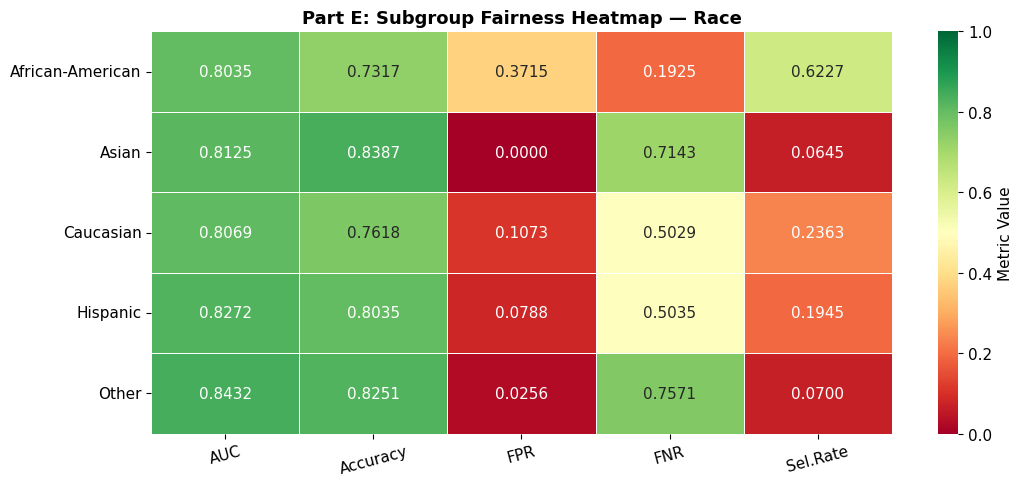

In [65]:
race_heat = (
    tbl_race
    .set_index("Subgroup")[["AUC", "Accuracy", "FPR", "FNR", "Sel.Rate"]]
    .apply(pd.to_numeric, errors="coerce")
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(race_heat, annot=True, fmt=".4f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={"label": "Metric Value"})
ax.set_title("Part E: Subgroup Fairness Heatmap — Race", fontsize=13, fontweight="bold")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
plt.tight_layout()
plt.savefig("partE_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


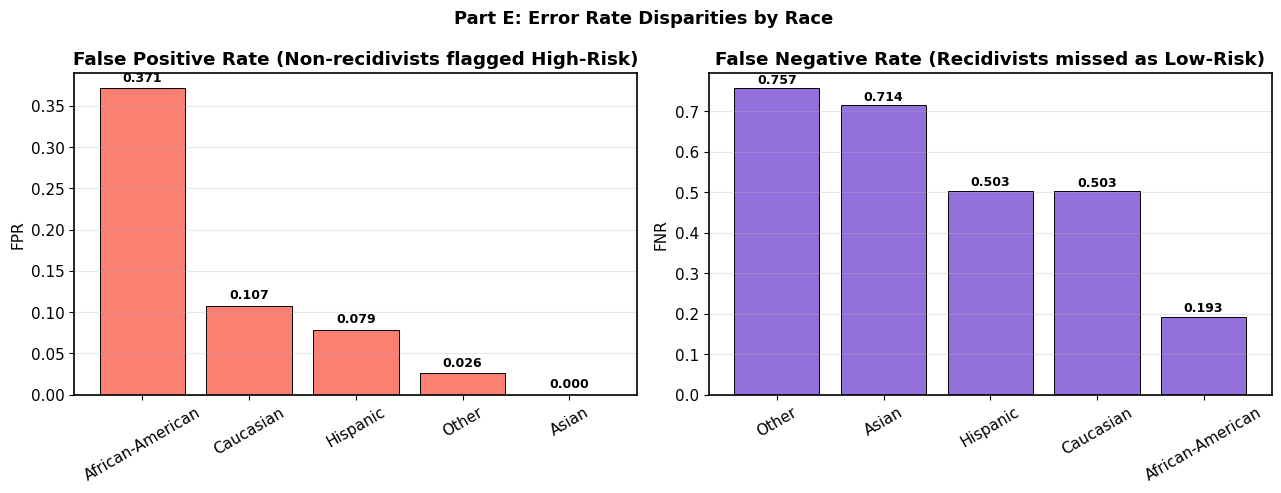

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

title_fpr = "False Positive Rate (Non-recidivists flagged High-Risk)"
title_fnr = "False Negative Rate (Recidivists missed as Low-Risk)"

for ax, metric, color, title in zip(
    axes,
    ["FPR", "FNR"],
    ["salmon", "mediumpurple"],
    [title_fpr, title_fnr]
):
    tbl_r = tbl_race.copy()
    tbl_r[metric] = pd.to_numeric(tbl_r[metric], errors="coerce")
    tbl_r = tbl_r.sort_values(metric, ascending=False)
    bars  = ax.bar(tbl_r["Subgroup"], tbl_r[metric],
                   color=color, edgecolor="black", linewidth=0.7)
    for bar, val in zip(bars, tbl_r[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Part E: Error Rate Disparities by Race", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("partE_fpr_fnr.png", dpi=150, bbox_inches="tight")
plt.show()


In [67]:
print("=== AUC Range Across Subgroups ===")
all_slices = pd.concat([tbl_race, tbl_sex, tbl_age], ignore_index=True)
for group in ["race", "sex", "age_cat"]:
    g        = all_slices[all_slices["Group"] == group]
    auc_vals = pd.to_numeric(g["AUC"], errors="coerce").dropna()
    auc_rng  = auc_vals.max() - auc_vals.min()
    flag     = "[!] HIGH VARIANCE" if auc_rng > 0.05 else "[ok] Acceptable"
    print(f"  {group:<12}: min={auc_vals.min():.4f}  max={auc_vals.max():.4f}"
          f"  range={auc_rng:.4f}  {flag}")


=== AUC Range Across Subgroups ===
  race        : min=0.8035  max=0.8432  range=0.0397  [ok] Acceptable
  sex         : min=0.8296  max=0.8310  range=0.0014  [ok] Acceptable
  age_cat     : min=0.7099  max=0.8533  range=0.1434  [!] HIGH VARIANCE


AUC range above 0.05 across a protected attribute means the model discriminates better for some groups than others. Lower AUC in a subgroup means predictions are less reliable for that group - the model's ranking of defendants by risk is noisier or systematically off. This is a separate problem from FPR/FNR disparity: a model can have equal error rates but unequal discrimination ability, or vice versa. Both should be reported.

**Summary of findings across parts A-E:**
- No distributional drift between train and test (Part A) - baseline check passed
- Model generalizes well with near-zero performance gaps (Part B)
- Race, sex, and age all carry direct predictive weight confirmed by counterfactual swaps (Part C)
- Priors_count is the strongest continuous predictor; its effect is not uniform across defendants (Part D)
- FPR is higher for African-American defendants than Caucasian defendants; AIR falls below the 0.80 threshold for multiple groups (Part E)
